In [14]:
# EXPERIMENT 6
import os
import time
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)

print("\nGPU INFORMATION")
print("----------------")
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU Available:", gpus)
    print("Training will use GPU acceleration.")
else:
    print("No GPU detected.")
    print("Training will use CPU.")

print("\nLibraries imported successfully!")

TensorFlow Version: 2.20.0
NumPy Version: 2.1.3

GPU INFORMATION
----------------
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training will use GPU acceleration.

Libraries imported successfully!


In [15]:
import os
import zipfile
import urllib.request

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"

zip_path = "/content/UCI_HAR_Dataset.zip"
extract_path = "/content/"

if not os.path.exists("/content/UCI HAR Dataset"):

    print("Downloading UCI HAR Dataset...")

    urllib.request.urlretrieve(dataset_url, zip_path)

    print("Download completed!")

    print("\nExtracting dataset...")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print("Extraction completed!")

else:
    print("Dataset already exists.")

print("\nDataset location:")
print("/content/UCI HAR Dataset")

Dataset already exists.

Dataset location:
/content/UCI HAR Dataset


In [16]:
base_path = "/content/UCI HAR Dataset"

print("Dataset directory:")
print(base_path)

print("\nFiles and folders:")

for item in os.listdir(base_path):
    print(" -", item)

Dataset directory:
/content/UCI HAR Dataset

Files and folders:
 - train
 - README.txt
 - features.txt
 - features_info.txt
 - activity_labels.txt
 - test
 - .DS_Store


In [17]:
sensor_names = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

print("Number of sensor channels:", len(sensor_names))

print("\nSensor channels:")
for i, sensor in enumerate(sensor_names, start=1):
    print(f"{i}. {sensor}")

Number of sensor channels: 9

Sensor channels:
1. body_acc_x
2. body_acc_y
3. body_acc_z
4. body_gyro_x
5. body_gyro_y
6. body_gyro_z
7. total_acc_x
8. total_acc_y
9. total_acc_z


In [18]:
def load_sensor_data(folder_path, prefix):
    """
    Loads the 9 raw inertial signal files.

    Output shape:
    (number_of_samples, 128, 9)
    """

    signals = []

    file_names = [
        f"body_acc_x_{prefix}.txt",
        f"body_acc_y_{prefix}.txt",
        f"body_acc_z_{prefix}.txt",

        f"body_gyro_x_{prefix}.txt",
        f"body_gyro_y_{prefix}.txt",
        f"body_gyro_z_{prefix}.txt",

        f"total_acc_x_{prefix}.txt",
        f"total_acc_y_{prefix}.txt",
        f"total_acc_z_{prefix}.txt"
    ]

    for file_name in file_names:

        file_path = os.path.join(
            folder_path,
            "Inertial Signals",
            file_name
        )

        data = np.loadtxt(file_path)

        signals.append(data)

    # Each element:
    # (N, 128)

    # Stack into:
    # (N, 128, 9)
    X = np.stack(signals, axis=-1)

    return X

In [19]:
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

print("Loading training signals...")

X_train_original = load_sensor_data(train_path, "train")

print("Loading testing signals...")

X_test_original = load_sensor_data(test_path, "test")

# Load labels
y_train_original = np.loadtxt(
    os.path.join(train_path, "y_train.txt")
).astype(int)

y_test_original = np.loadtxt(
    os.path.join(test_path, "y_test.txt")
).astype(int)

# Convert labels from 1-6 to 0-5
y_train_original = y_train_original - 1
y_test_original = y_test_original - 1

print("\nDATA LOADED SUCCESSFULLY")
print("========================")

print("Original training input shape :", X_train_original.shape)
print("Original testing input shape  :", X_test_original.shape)

print("Training labels shape         :", y_train_original.shape)
print("Testing labels shape          :", y_test_original.shape)

print("\nNumber of classes:", len(np.unique(y_train_original)))
print("Number of features per time step:", X_train_original.shape[2])
print("Sequence length:", X_train_original.shape[1])

Loading training signals...
Loading testing signals...

DATA LOADED SUCCESSFULLY
Original training input shape : (7352, 128, 9)
Original testing input shape  : (2947, 128, 9)
Training labels shape         : (7352,)
Testing labels shape          : (2947,)

Number of classes: 6
Number of features per time step: 9
Sequence length: 128


In [20]:
# COMBINE DATA

X_all = np.concatenate(
    [X_train_original, X_test_original],
    axis=0
)

y_all = np.concatenate(
    [y_train_original, y_test_original],
    axis=0
)

print("Combined dataset shape:", X_all.shape)
print("Combined labels shape :", y_all.shape)

# FIRST SPLIT: 70% TRAIN, 30% TEMPORARY

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all,
    y_all,
    test_size=0.30,
    random_state=42,
    stratify=y_all
)

# SECOND SPLIT:
# 50% TEMP -> 15% VALIDATION
# 50% TEMP -> 15% TEST

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nFINAL DATA SPLIT")
print("================")

print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)

print("\nLabels:")
print("Training   :", y_train.shape)
print("Validation :", y_val.shape)
print("Testing    :", y_test.shape)

Combined dataset shape: (10299, 128, 9)
Combined labels shape : (10299,)

FINAL DATA SPLIT
Training   : (7209, 128, 9)
Validation : (1545, 128, 9)
Testing    : (1545, 128, 9)

Labels:
Training   : (7209,)
Validation : (1545,)
Testing    : (1545,)


In [21]:
# CLASS DISTRIBUTION

activity_names = [
    "WALKING",
    "WALKING UPSTAIRS",
    "WALKING DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

print("CLASS DISTRIBUTION")
print("==================")

distribution = pd.DataFrame({
    "Activity": activity_names,
    "Train": [
        np.sum(y_train == i) for i in range(6)
    ],
    "Validation": [
        np.sum(y_val == i) for i in range(6)
    ],
    "Test": [
        np.sum(y_test == i) for i in range(6)
    ]
})

print(distribution)

CLASS DISTRIBUTION
             Activity  Train  Validation  Test
0             WALKING   1205         258   259
1    WALKING UPSTAIRS   1081         232   231
2  WALKING DOWNSTAIRS    984         211   211
3             SITTING   1244         266   267
4            STANDING   1334         286   286
5              LAYING   1361         292   291


In [22]:
# NORMALIZATION

# Reshape training data:
# (samples, 128, 9)
#       ↓
# (samples*128, 9)

scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, 9)

# Fit ONLY on training data
scaler.fit(X_train_2d)

# Transform all sets
X_train = scaler.transform(
    X_train.reshape(-1, 9)
).reshape(X_train.shape)

X_val = scaler.transform(
    X_val.reshape(-1, 9)
).reshape(X_val.shape)

X_test = scaler.transform(
    X_test.reshape(-1, 9)
).reshape(X_test.shape)

print("NORMALIZATION COMPLETED")
print("======================")

print("Training shape   :", X_train.shape)
print("Validation shape :", X_val.shape)
print("Testing shape    :", X_test.shape)

print("\nInput tensor format:")
print("(N, T, F)")
print("N = Number of sequences")
print("T = 128 time steps")
print("F = 9 sensor features")

NORMALIZATION COMPLETED
Training shape   : (7209, 128, 9)
Validation shape : (1545, 128, 9)
Testing shape    : (1545, 128, 9)

Input tensor format:
(N, T, F)
N = Number of sequences
T = 128 time steps
F = 9 sensor features


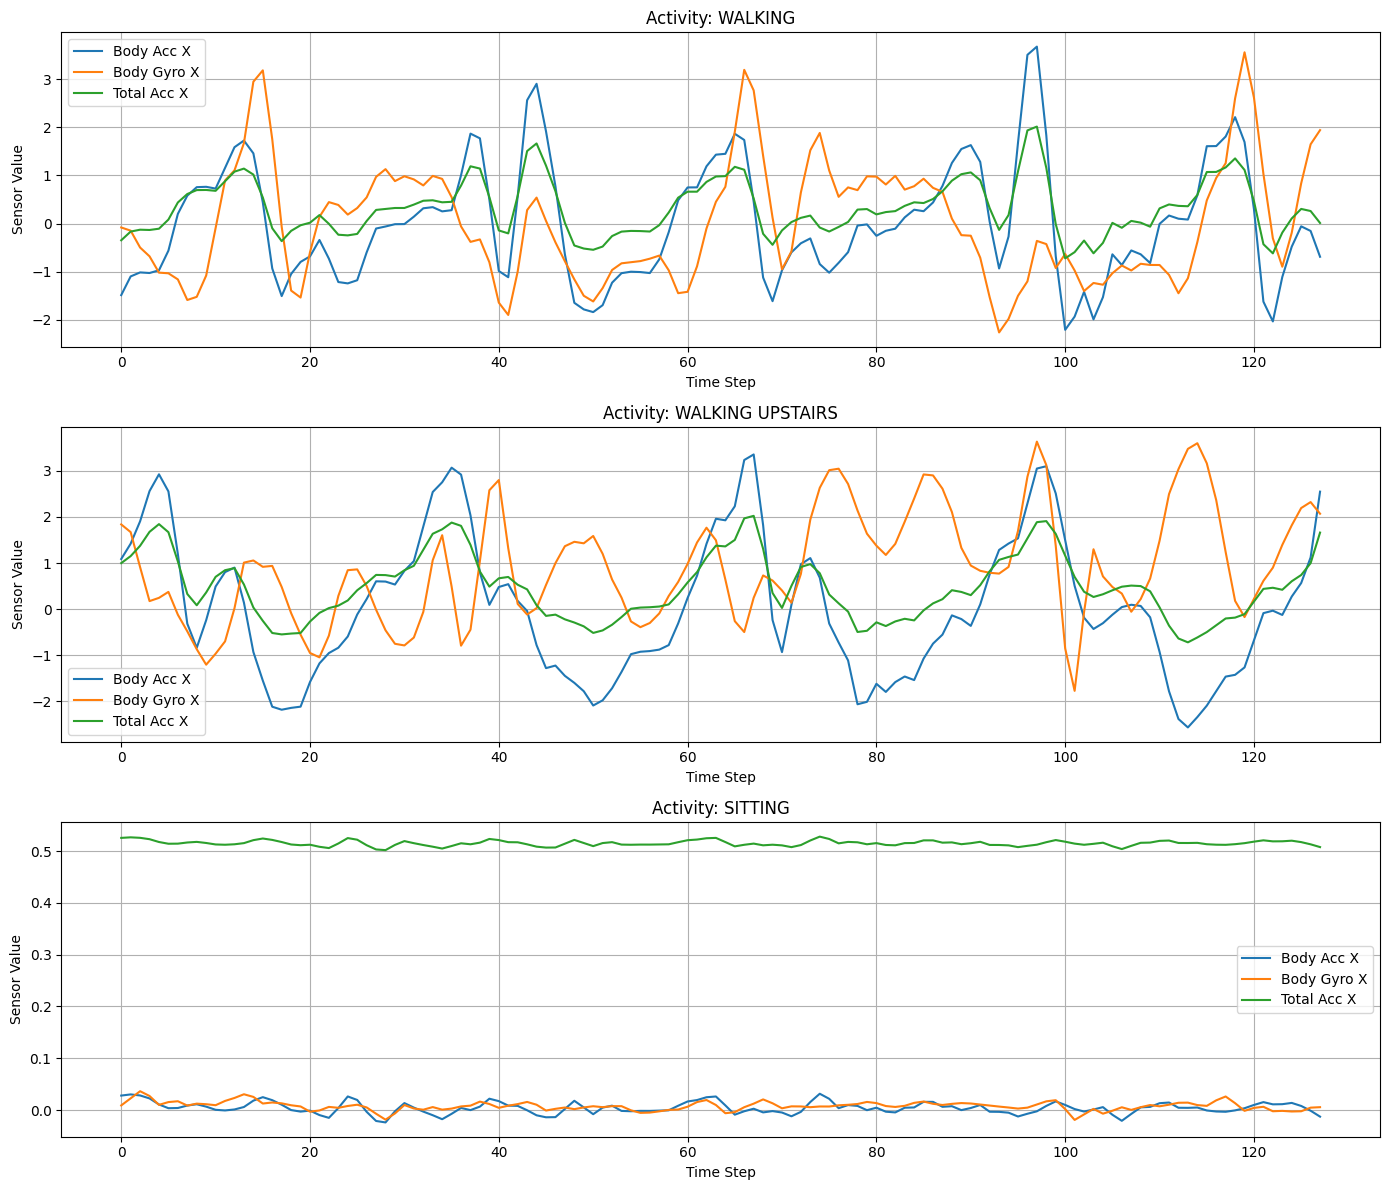

In [23]:
# TEMPORAL SENSOR VISUALIZATION

selected_classes = [0, 1, 3]

fig, axes = plt.subplots(
    len(selected_classes),
    1,
    figsize=(14, 12)
)

for row, class_id in enumerate(selected_classes):

    # Find first sample belonging to this class
    index = np.where(y_train == class_id)[0][0]

    sample = X_train[index]

    axes[row].plot(
        sample[:, 0],
        label="Body Acc X"
    )

    axes[row].plot(
        sample[:, 3],
        label="Body Gyro X"
    )

    axes[row].plot(
        sample[:, 6],
        label="Total Acc X"
    )

    axes[row].set_title(
        f"Activity: {activity_names[class_id]}"
    )

    axes[row].set_xlabel("Time Step")
    axes[row].set_ylabel("Sensor Value")

    axes[row].legend()
    axes[row].grid(True)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# CELL 11: VERIFY SEQUENCE REPRESENTATION
# ============================================================

print("SEQUENCE DATA REPRESENTATION")
print("============================")

print("Training input shape   :", X_train.shape)
print("Validation input shape :", X_val.shape)
print("Testing input shape    :", X_test.shape)

print("\nOne sample shape       :", X_train[0].shape)

print("\nMeaning of dimensions:")
print("N = Number of sequences")
print("T = Number of time steps = 128")
print("F = Number of features/channels = 9")

print("\nExpected format:")
print("X ∈ R^(N × 128 × 9)")

print("\nNumber of classes:", len(activity_names))
print("Sequence length :", X_train.shape[1])
print("Features/time step:", X_train.shape[2])

SEQUENCE DATA REPRESENTATION
Training input shape   : (7209, 128, 9)
Validation input shape : (1545, 128, 9)
Testing input shape    : (1545, 128, 9)

One sample shape       : (128, 9)

Meaning of dimensions:
N = Number of sequences
T = Number of time steps = 128
F = Number of features/channels = 9

Expected format:
X ∈ R^(N × 128 × 9)

Number of classes: 6
Sequence length : 128
Features/time step: 9


In [25]:
# ============================================================
# CELL 12: VANILLA RNN MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

rnn_model = Sequential([

    SimpleRNN(
        32,
        input_shape=(128, 9)
    ),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        6,
        activation="softmax"
    )
])

rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("VANILLA RNN ARCHITECTURE")
print("========================")

rnn_model.summary()

VANILLA RNN ARCHITECTURE


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# ============================================================
# CELL 13: TRAIN VANILLA RNN
# ============================================================

print("Starting Vanilla RNN training...")
print("--------------------------------")

rnn_start_time = time.time()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

rnn_training_time = time.time() - rnn_start_time

print("\n========================================")
print("RNN TRAINING COMPLETED")
print("========================================")

print(
    f"Total RNN Training Time: "
    f"{rnn_training_time:.2f} seconds"
)

print(
    f"Total RNN Training Time: "
    f"{rnn_training_time/60:.2f} minutes"
)

Starting Vanilla RNN training...
--------------------------------
Epoch 1/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.5372 - loss: 1.2249 - val_accuracy: 0.6117 - val_loss: 0.9336
Epoch 2/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6477 - loss: 0.8064 - val_accuracy: 0.7152 - val_loss: 0.6607
Epoch 3/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6968 - loss: 0.6640 - val_accuracy: 0.7450 - val_loss: 0.5865
Epoch 4/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7093 - loss: 0.6485 - val_accuracy: 0.7314 - val_loss: 0.6044
Epoch 5/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5994 - loss: 0.9488 - val_accuracy: 0.7029 - val_loss: 0.6886
Epoch 6/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6717 - loss: 0.7459 - val_accuracy: 0.7385 - val_loss: 0.6260
Epoch 7/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7037 - loss: 0.6585 - val_accuracy: 0.7385 - val_loss: 0.5921
Epoch 8/30
226/226 ━━━━━━━━━━━━

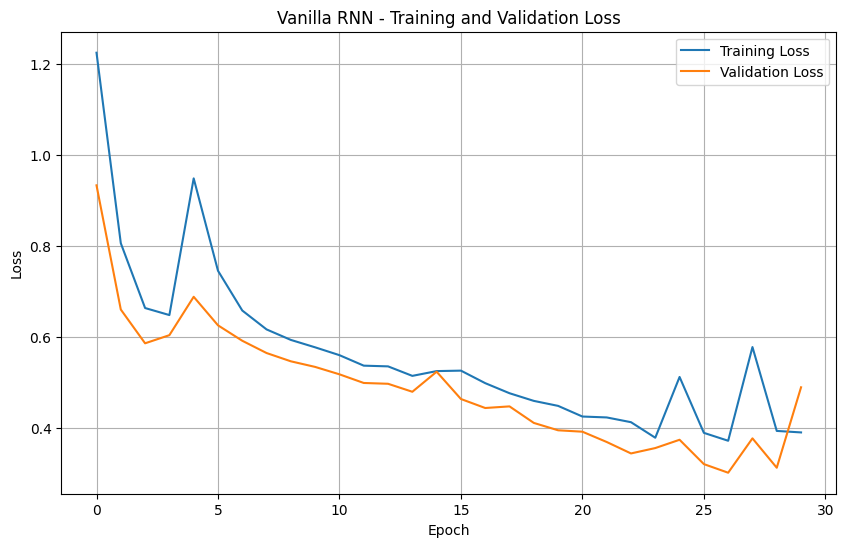

In [27]:
# ============================================================
# CELL 14: RNN LOSS CURVES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    rnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    rnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Vanilla RNN - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

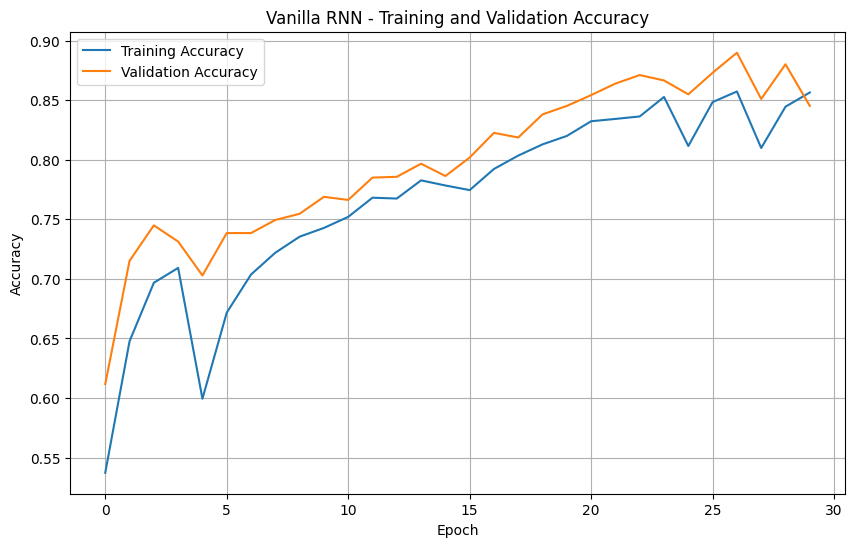

In [28]:
# CELL 15: RNN ACCURACY CURVES

plt.figure(figsize=(10, 6))

plt.plot(
    rnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    rnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Vanilla RNN - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [29]:
# ============================================================
# CELL 16: RNN TEST EVALUATION
# ============================================================

rnn_test_loss, rnn_test_accuracy = rnn_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("RNN TEST EVALUATION")
print("===================")

print(f"Test Loss     : {rnn_test_loss:.4f}")
print(f"Test Accuracy : {rnn_test_accuracy * 100:.2f}%")

RNN TEST EVALUATION
Test Loss     : 0.4768
Test Accuracy : 84.08%


In [30]:
# ============================================================
# CELL 17: RNN CLASSIFICATION METRICS
# ============================================================

rnn_probabilities = rnn_model.predict(
    X_test,
    verbose=0
)

rnn_predictions = np.argmax(
    rnn_probabilities,
    axis=1
)

rnn_accuracy = accuracy_score(
    y_test,
    rnn_predictions
)

rnn_precision = precision_score(
    y_test,
    rnn_predictions,
    average="macro"
)

rnn_recall = recall_score(
    y_test,
    rnn_predictions,
    average="macro"
)

rnn_f1 = f1_score(
    y_test,
    rnn_predictions,
    average="macro"
)

print("RNN PERFORMANCE METRICS")
print("=======================")

print(f"Accuracy        : {rnn_accuracy * 100:.2f}%")
print(f"Macro Precision : {rnn_precision * 100:.2f}%")
print(f"Macro Recall    : {rnn_recall * 100:.2f}%")
print(f"Macro F1-score  : {rnn_f1 * 100:.2f}%")

RNN PERFORMANCE METRICS
Accuracy        : 84.08%
Macro Precision : 83.65%
Macro Recall    : 83.50%
Macro F1-score  : 83.49%


In [31]:
# ============================================================
# CELL 18: RNN CLASSIFICATION REPORT
# ============================================================

print("RNN CLASSIFICATION REPORT")
print("=========================")

print(
    classification_report(
        y_test,
        rnn_predictions,
        target_names=activity_names
    )
)

RNN CLASSIFICATION REPORT
                    precision    recall  f1-score   support

           WALKING       0.82      0.73      0.77       259
  WALKING UPSTAIRS       0.83      0.81      0.82       231
WALKING DOWNSTAIRS       0.75      0.79      0.77       211
           SITTING       0.84      0.81      0.83       267
          STANDING       0.79      0.87      0.83       286
            LAYING       0.99      1.00      1.00       291

          accuracy                           0.84      1545
         macro avg       0.84      0.84      0.83      1545
      weighted avg       0.84      0.84      0.84      1545



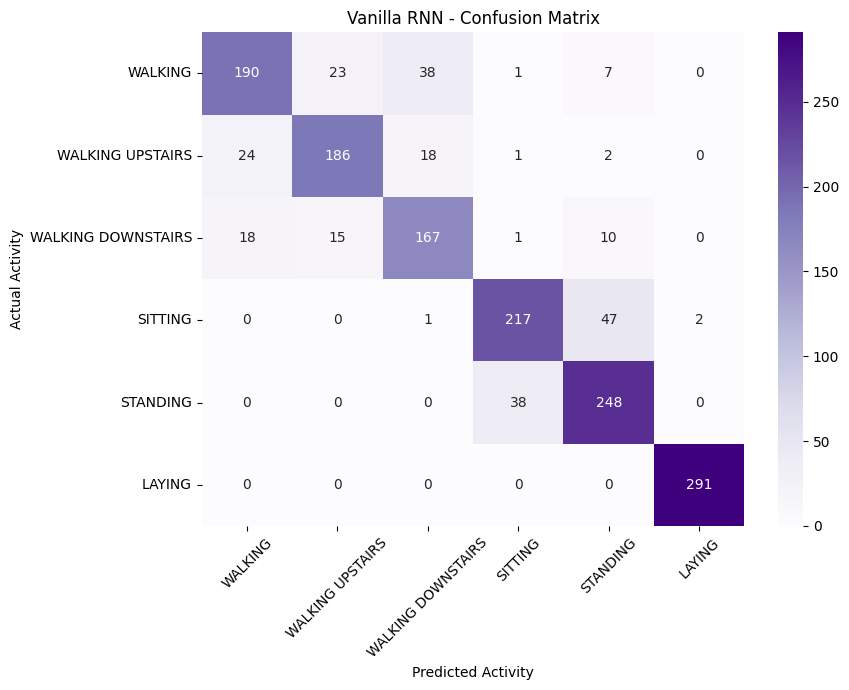

In [124]:
# ============================================================
# CELL 19: RNN CONFUSION MATRIX
# ============================================================

rnn_cm = confusion_matrix(
    y_test,
    rnn_predictions
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    rnn_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.title("Vanilla RNN - Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# CELL 20: RNN SUMMARY
# ============================================================

rnn_parameters = rnn_model.count_params()

print("========================================")
print("VANILLA RNN FINAL SUMMARY")
print("========================================")

print(f"Test Accuracy       : {rnn_accuracy * 100:.2f}%")
print(f"Macro Precision     : {rnn_precision * 100:.2f}%")
print(f"Macro Recall        : {rnn_recall * 100:.2f}%")
print(f"Macro F1-score      : {rnn_f1 * 100:.2f}%")
print(f"Trainable Parameters: {rnn_parameters:,}")
print(f"Training Time       : {rnn_training_time:.2f} seconds")

print("\nModel Input:")
print("(128 time steps × 9 features)")

print("\nNumber of Classes:", 6)

VANILLA RNN FINAL SUMMARY
Test Accuracy       : 84.08%
Macro Precision     : 83.65%
Macro Recall        : 83.50%
Macro F1-score      : 83.49%
Trainable Parameters: 1,974
Training Time       : 80.37 seconds

Model Input:
(128 time steps × 9 features)

Number of Classes: 6


In [34]:
# ============================================================
# CELL 21: LSTM MODEL
# ============================================================

from tensorflow.keras.layers import LSTM

lstm_model = Sequential([

    LSTM(
        32,
        input_shape=(128, 9)
    ),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        6,
        activation="softmax"
    )
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("LSTM ARCHITECTURE")
print("=================")

lstm_model.summary()

LSTM ARCHITECTURE


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# ============================================================
# CELL 22: TRAIN LSTM
# ============================================================

print("Starting LSTM training...")
print("--------------------------------")

lstm_start_time = time.time()

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

lstm_training_time = time.time() - lstm_start_time

print("\n========================================")
print("LSTM TRAINING COMPLETED")
print("========================================")

print(
    f"Total LSTM Training Time: "
    f"{lstm_training_time:.2f} seconds"
)

print(
    f"Total LSTM Training Time: "
    f"{lstm_training_time/60:.2f} minutes"
)

Starting LSTM training...
--------------------------------
Epoch 1/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5721 - loss: 1.1380 - val_accuracy: 0.8298 - val_loss: 0.5429
Epoch 2/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8674 - loss: 0.4284 - val_accuracy: 0.8809 - val_loss: 0.3596
Epoch 3/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9091 - loss: 0.2967 - val_accuracy: 0.9249 - val_loss: 0.2198
Epoch 4/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9213 - loss: 0.2458 - val_accuracy: 0.9126 - val_loss: 0.2275
Epoch 5/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9136 - loss: 0.2356 - val_accuracy: 0.9217 - val_loss: 0.1834
Epoch 6/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9398 - loss: 0.1724 - val_accuracy: 0.9398 - val_loss: 0.1565
Epoch 7/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9408 - loss: 0.1560 - val_accuracy: 0.9534 - val_loss: 0.1291
Epoch 8/30
226/226 ━━━━━━━━━━━━━━━━━━━

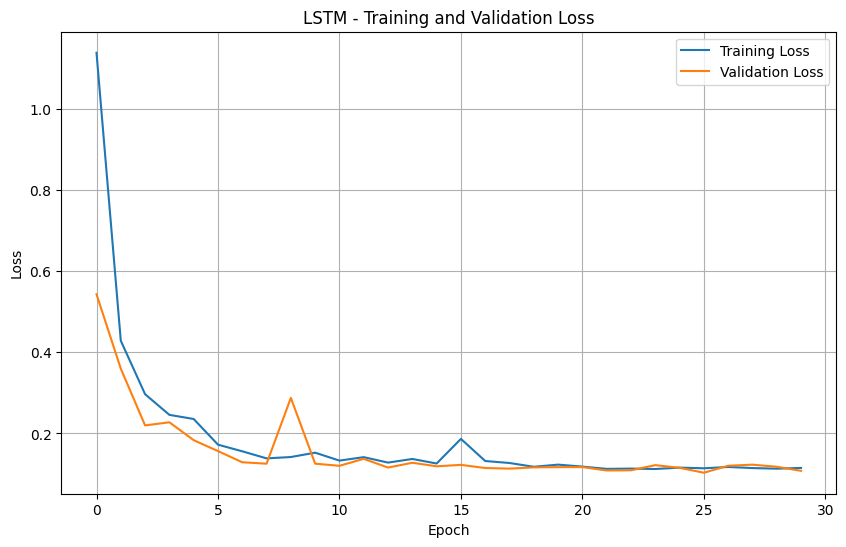

In [36]:
# ============================================================
# CELL 23: LSTM LOSS CURVES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

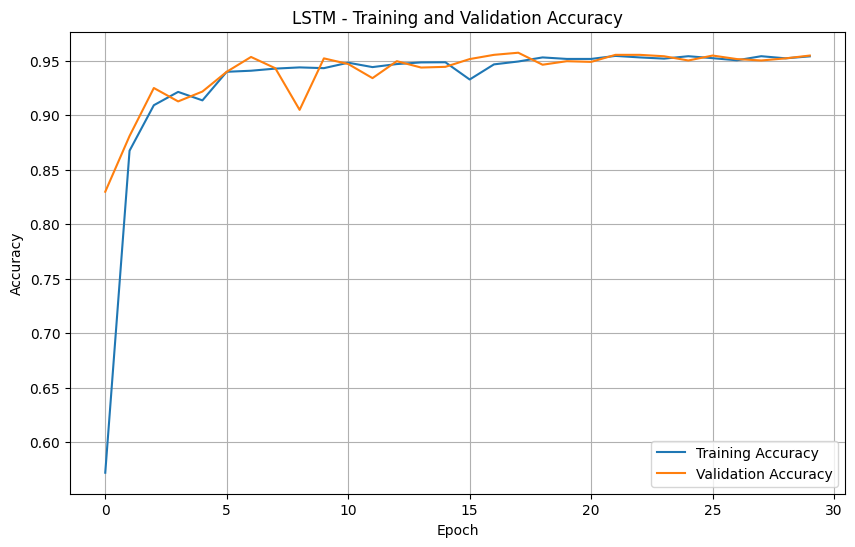

In [37]:
# ============================================================
# CELL 24: LSTM ACCURACY CURVES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    lstm_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("LSTM - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [38]:
# ============================================================
# CELL 25: LSTM TEST EVALUATION
# ============================================================

lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("LSTM TEST EVALUATION")
print("====================")

print(f"Test Loss     : {lstm_test_loss:.4f}")
print(f"Test Accuracy : {lstm_test_accuracy * 100:.2f}%")

LSTM TEST EVALUATION
Test Loss     : 0.1240
Test Accuracy : 95.02%


In [39]:
# ============================================================
# CELL 26: LSTM CLASSIFICATION METRICS
# ============================================================

lstm_probabilities = lstm_model.predict(
    X_test,
    verbose=0
)

lstm_predictions = np.argmax(
    lstm_probabilities,
    axis=1
)

lstm_accuracy = accuracy_score(
    y_test,
    lstm_predictions
)

lstm_precision = precision_score(
    y_test,
    lstm_predictions,
    average="macro"
)

lstm_recall = recall_score(
    y_test,
    lstm_predictions,
    average="macro"
)

lstm_f1 = f1_score(
    y_test,
    lstm_predictions,
    average="macro"
)

print("LSTM PERFORMANCE METRICS")
print("========================")

print(f"Accuracy        : {lstm_accuracy * 100:.2f}%")
print(f"Macro Precision : {lstm_precision * 100:.2f}%")
print(f"Macro Recall    : {lstm_recall * 100:.2f}%")
print(f"Macro F1-score  : {lstm_f1 * 100:.2f}%")

LSTM PERFORMANCE METRICS
Accuracy        : 95.02%
Macro Precision : 95.37%
Macro Recall    : 95.38%
Macro F1-score  : 95.34%


In [40]:
# ============================================================
# CELL 27: LSTM CLASSIFICATION REPORT
# ============================================================

print("LSTM CLASSIFICATION REPORT")
print("==========================")

print(
    classification_report(
        y_test,
        lstm_predictions,
        target_names=activity_names
    )
)

LSTM CLASSIFICATION REPORT
                    precision    recall  f1-score   support

           WALKING       1.00      1.00      1.00       259
  WALKING UPSTAIRS       1.00      1.00      1.00       231
WALKING DOWNSTAIRS       1.00      1.00      1.00       211
           SITTING       0.84      0.89      0.86       267
          STANDING       0.89      0.84      0.86       286
            LAYING       1.00      1.00      1.00       291

          accuracy                           0.95      1545
         macro avg       0.95      0.95      0.95      1545
      weighted avg       0.95      0.95      0.95      1545



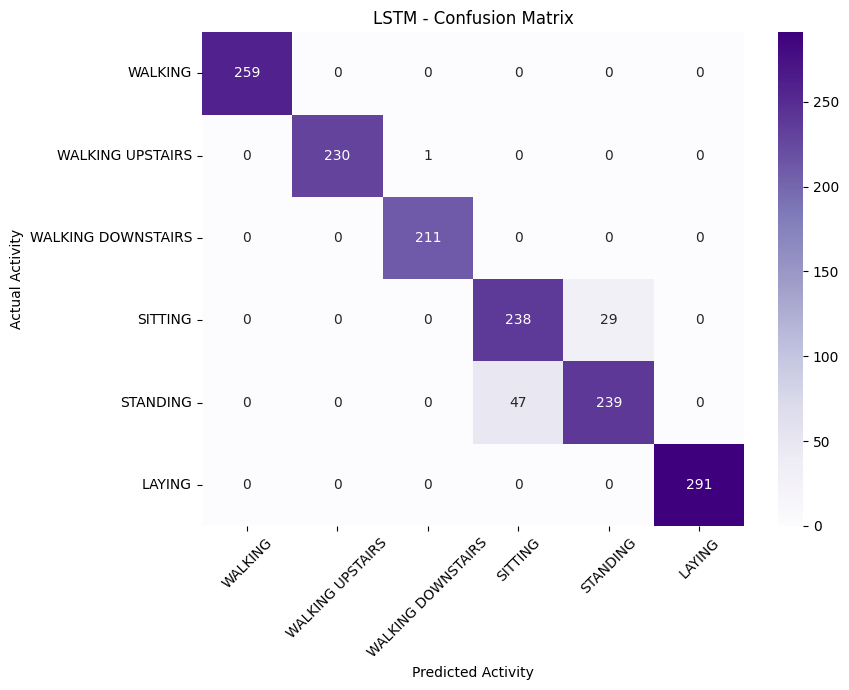

In [123]:
# ============================================================
# CELL 28: LSTM CONFUSION MATRIX
# ============================================================

lstm_cm = confusion_matrix(
    y_test,
    lstm_predictions
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    lstm_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.title("LSTM - Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# CELL 29: LSTM FINAL SUMMARY
# ============================================================

lstm_parameters = lstm_model.count_params()

print("========================================")
print("LSTM FINAL SUMMARY")
print("========================================")

print(f"Test Accuracy       : {lstm_accuracy * 100:.2f}%")
print(f"Macro Precision     : {lstm_precision * 100:.2f}%")
print(f"Macro Recall        : {lstm_recall * 100:.2f}%")
print(f"Macro F1-score      : {lstm_f1 * 100:.2f}%")
print(f"Trainable Parameters: {lstm_parameters:,}")
print(f"Training Time       : {lstm_training_time:.2f} seconds")

print("\nModel Input:")
print("(128 time steps × 9 features)")

print("\nNumber of Classes:", 6)

LSTM FINAL SUMMARY
Test Accuracy       : 95.02%
Macro Precision     : 95.37%
Macro Recall        : 95.38%
Macro F1-score      : 95.34%
Trainable Parameters: 6,006
Training Time       : 79.51 seconds

Model Input:
(128 time steps × 9 features)

Number of Classes: 6


In [43]:
gru_model = Sequential([
    GRU(32, input_shape=(128, 9)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(6, activation="softmax")
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
start_time = time.time()

gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

gru_training_time = time.time() - start_time

print(f"GRU Training Time: {gru_training_time:.2f} seconds")

Epoch 1/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5010 - loss: 1.2392 - val_accuracy: 0.6673 - val_loss: 0.7924
Epoch 2/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7099 - loss: 0.6482 - val_accuracy: 0.7955 - val_loss: 0.5456
Epoch 3/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8470 - loss: 0.4250 - val_accuracy: 0.9223 - val_loss: 0.2498
Epoch 4/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9277 - loss: 0.2121 - val_accuracy: 0.9424 - val_loss: 0.1538
Epoch 5/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9341 - loss: 0.1660 - val_accuracy: 0.9456 - val_loss: 0.1416
Epoch 6/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9390 - loss: 0.1535 - val_accuracy: 0.9424 - val_loss: 0.1343
Epoch 7/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9441 - loss: 0.1465 - val_accuracy: 0.9340 - val_loss: 0.1300
Epoch 8/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9395 - loss: 0.1575 - val_accurac

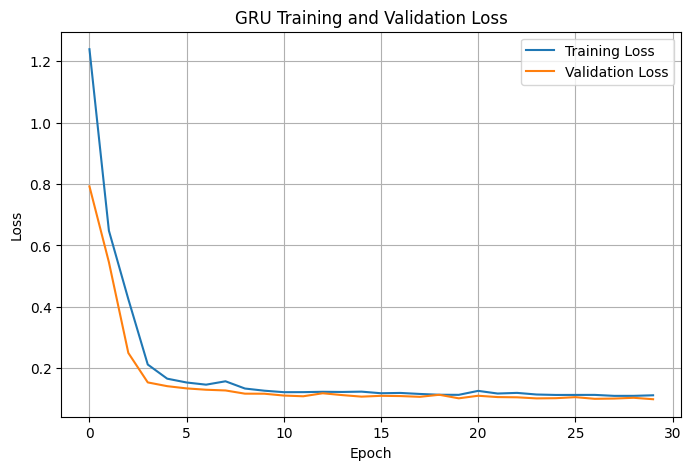

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(gru_history.history["loss"], label="Training Loss")
plt.plot(gru_history.history["val_loss"], label="Validation Loss")

plt.title("GRU Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

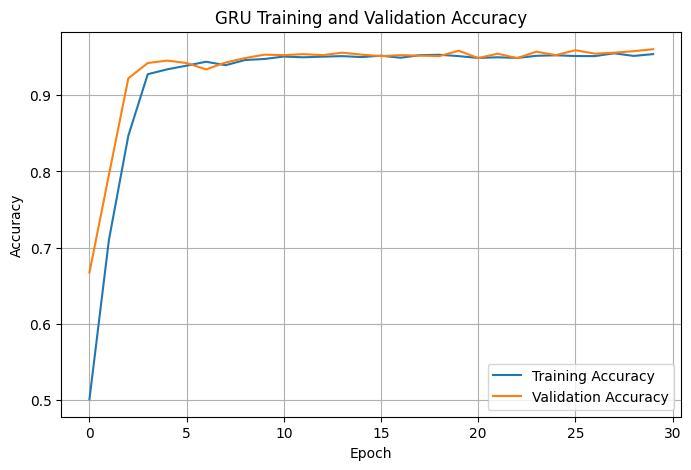

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(gru_history.history["accuracy"], label="Training Accuracy")
plt.plot(gru_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("GRU Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
gru_test_loss, gru_test_accuracy = gru_model.evaluate(
    X_test, y_test, verbose=0
)

print(f"GRU Test Loss     : {gru_test_loss:.4f}")
print(f"GRU Test Accuracy : {gru_test_accuracy:.4f}")

GRU Test Loss     : 0.1258
GRU Test Accuracy : 0.9508


In [48]:
gru_probabilities = gru_model.predict(X_test, verbose=0)

gru_predictions = np.argmax(gru_probabilities, axis=1)

gru_accuracy = accuracy_score(y_test, gru_predictions)

gru_precision = precision_score(
    y_test, gru_predictions, average="macro"
)

gru_recall = recall_score(
    y_test, gru_predictions, average="macro"
)

gru_f1 = f1_score(
    y_test, gru_predictions, average="macro"
)

print(f"GRU Accuracy       : {gru_accuracy:.4f}")
print(f"GRU Macro Precision: {gru_precision:.4f}")
print(f"GRU Macro Recall   : {gru_recall:.4f}")
print(f"GRU Macro F1       : {gru_f1:.4f}")

GRU Accuracy       : 0.9508
GRU Macro Precision: 0.9546
GRU Macro Recall   : 0.9541
GRU Macro F1       : 0.9538


In [49]:
activity_names = [
    "WALKING",
    "WALKING UPSTAIRS",
    "WALKING DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

print("GRU Classification Report\n")

print(
    classification_report(
        y_test,
        gru_predictions,
        target_names=activity_names
    )
)

GRU Classification Report

                    precision    recall  f1-score   support

           WALKING       0.99      1.00      1.00       259
  WALKING UPSTAIRS       1.00      1.00      1.00       231
WALKING DOWNSTAIRS       1.00      0.99      1.00       211
           SITTING       0.83      0.91      0.87       267
          STANDING       0.91      0.83      0.87       286
            LAYING       1.00      1.00      1.00       291

          accuracy                           0.95      1545
         macro avg       0.95      0.95      0.95      1545
      weighted avg       0.95      0.95      0.95      1545



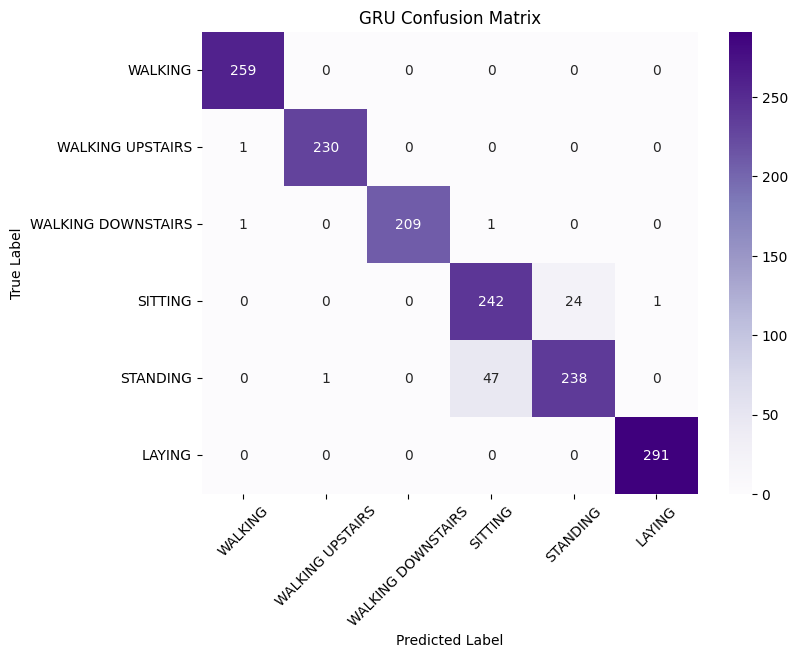

In [122]:
gru_cm = confusion_matrix(y_test, gru_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    gru_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.title("GRU Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [51]:
gru_parameters = gru_model.count_params()

print("GRU Model Summary")
gru_model.summary()

print(f"\nTrainable Parameters: {gru_parameters}")
print(f"Training Time: {gru_training_time:.2f} seconds")

GRU Model Summary


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,276 (55.77 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,518 (37.18 KB)


Trainable Parameters: 4758
Training Time: 73.99 seconds


In [52]:
comparison_df = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Test Accuracy": [
        rnn_accuracy,
        lstm_accuracy,
        gru_accuracy
    ],
    "Macro Precision": [
        rnn_precision,
        lstm_precision,
        gru_precision
    ],
    "Macro Recall": [
        rnn_recall,
        lstm_recall,
        gru_recall
    ],
    "Macro F1": [
        rnn_f1,
        lstm_f1,
        gru_f1
    ],
    "Parameters": [
        rnn_parameters,
        lstm_parameters,
        gru_parameters
    ],
    "Training Time (sec)": [
        rnn_training_time,
        lstm_training_time,
        gru_training_time
    ]
})

comparison_df

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Parameters,Training Time (sec)
0,RNN,0.840777,0.836488,0.835020,0.834873,1974,80.370239
1,LSTM,0.950162,0.953694,0.953787,0.953434,6006,79.508599
2,GRU,0.950809,0.954577,0.954121,0.953817,4758,73.986158


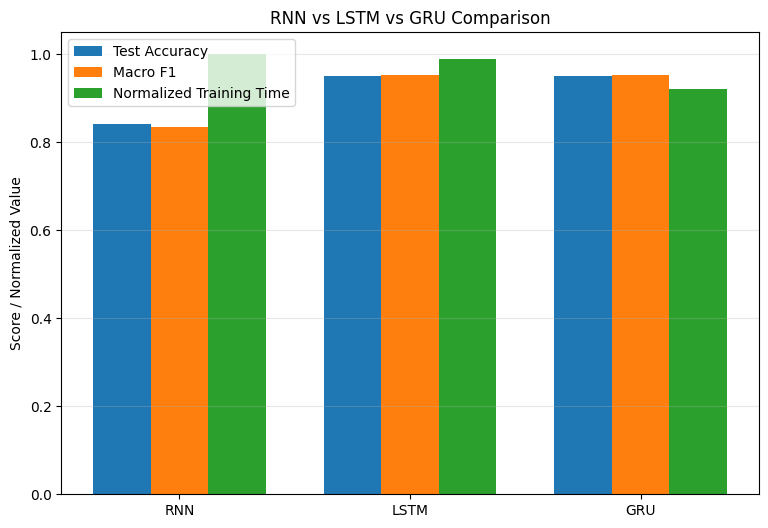

In [53]:
plt.figure(figsize=(9, 6))

x = np.arange(len(comparison_df))
width = 0.25

plt.bar(
    x - width,
    comparison_df["Test Accuracy"],
    width,
    label="Test Accuracy"
)

plt.bar(
    x,
    comparison_df["Macro F1"],
    width,
    label="Macro F1"
)

# Normalize training time for visual comparison
normalized_time = (
    comparison_df["Training Time (sec)"] /
    comparison_df["Training Time (sec)"].max()
)

plt.bar(
    x + width,
    normalized_time,
    width,
    label="Normalized Training Time"
)

plt.xticks(x, comparison_df["Model"])
plt.ylabel("Score / Normalized Value")
plt.title("RNN vs LSTM vs GRU Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [54]:
print("========== FINAL MODEL COMPARISON ==========\n")

for _, row in comparison_df.iterrows():
    print(f"Model: {row['Model']}")
    print(f"Test Accuracy       : {row['Test Accuracy']:.4f}")
    print(f"Macro Precision     : {row['Macro Precision']:.4f}")
    print(f"Macro Recall        : {row['Macro Recall']:.4f}")
    print(f"Macro F1            : {row['Macro F1']:.4f}")
    print(f"Parameters          : {int(row['Parameters'])}")
    print(f"Training Time       : {row['Training Time (sec)']:.2f} seconds")
    print("--------------------------------------------")

========== FINAL MODEL COMPARISON ==========

Model: RNN
Test Accuracy       : 0.8408
Macro Precision     : 0.8365
Macro Recall        : 0.8350
Macro F1            : 0.8349
Parameters          : 1974
Training Time       : 80.37 seconds
--------------------------------------------
Model: LSTM
Test Accuracy       : 0.9502
Macro Precision     : 0.9537
Macro Recall        : 0.9538
Macro F1            : 0.9534
Parameters          : 6006
Training Time       : 79.51 seconds
--------------------------------------------
Model: GRU
Test Accuracy       : 0.9508
Macro Precision     : 0.9546
Macro Recall        : 0.9541
Macro F1            : 0.9538
Parameters          : 4758
Training Time       : 73.99 seconds
--------------------------------------------


In [55]:
sequence_lengths = [32, 64, 128]

sequence_results = []

print("Available sequence lengths:", sequence_lengths)

Available sequence lengths: [32, 64, 128]


In [56]:
def prepare_sequence_length_data(X_train, X_val, X_test, sequence_length):
    X_train_seq = X_train[:, :sequence_length, :]
    X_val_seq = X_val[:, :sequence_length, :]
    X_test_seq = X_test[:, :sequence_length, :]

    return X_train_seq, X_val_seq, X_test_seq

In [57]:
def build_recurrent_model(model_type, sequence_length):

    if model_type == "RNN":
        recurrent_layer = SimpleRNN(32)

    elif model_type == "LSTM":
        recurrent_layer = LSTM(32)

    elif model_type == "GRU":
        recurrent_layer = GRU(32)

    model = Sequential([
        recurrent_layer,
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(6, activation="softmax")
    ])

    model.build(input_shape=(None, sequence_length, 9))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [58]:
for sequence_length in sequence_lengths:

    print("\n" + "=" * 60)
    print(f"SEQUENCE LENGTH = {sequence_length}")
    print("=" * 60)

    X_train_seq, X_val_seq, X_test_seq = prepare_sequence_length_data(
        X_train, X_val, X_test, sequence_length
    )

    for model_type in ["RNN", "LSTM", "GRU"]:

        print(f"\nTraining {model_type}...")

        model = build_recurrent_model(
            model_type,
            sequence_length
        )

        model.fit(
            X_train_seq,
            y_train,
            validation_data=(X_val_seq, y_val),
            epochs=30,
            batch_size=32,
            verbose=0
        )

        probabilities = model.predict(
            X_test_seq,
            verbose=0
        )

        predictions = np.argmax(
            probabilities,
            axis=1
        )

        f1 = f1_score(
            y_test,
            predictions,
            average="macro"
        )

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        sequence_results.append({
            "Sequence Length": sequence_length,
            "Model": model_type,
            "Test Accuracy": accuracy,
            "Macro F1": f1
        })

        print(
            f"{model_type} -> "
            f"Accuracy: {accuracy:.4f}, "
            f"Macro F1: {f1:.4f}"
        )


SEQUENCE LENGTH = 32

Training RNN...
RNN -> Accuracy: 0.8673, Macro F1: 0.8648

Training LSTM...
LSTM -> Accuracy: 0.9333, Macro F1: 0.9363

Training GRU...
GRU -> Accuracy: 0.9333, Macro F1: 0.9352

SEQUENCE LENGTH = 64

Training RNN...
RNN -> Accuracy: 0.8764, Macro F1: 0.8734

Training LSTM...
LSTM -> Accuracy: 0.9437, Macro F1: 0.9465

Training GRU...
GRU -> Accuracy: 0.9450, Macro F1: 0.9483

SEQUENCE LENGTH = 128

Training RNN...
RNN -> Accuracy: 0.8939, Macro F1: 0.8945

Training LSTM...
LSTM -> Accuracy: 0.8634, Macro F1: 0.8546

Training GRU...
GRU -> Accuracy: 0.9456, Macro F1: 0.9493


In [59]:
sequence_results_df = pd.DataFrame(sequence_results)

sequence_results_df

,Sequence Length,Model,Test Accuracy,Macro F1
0,32,RNN,0.867314,0.864766
1,32,LSTM,0.933333,0.936260
2,32,GRU,0.933333,0.935238
3,64,RNN,0.876375,0.873351
4,64,LSTM,0.943689,0.946461
5,64,GRU,0.944984,0.948264
6,128,RNN,0.893851,0.894473
7,128,LSTM,0.863430,0.854648
8,128,GRU,0.945631,0.949321


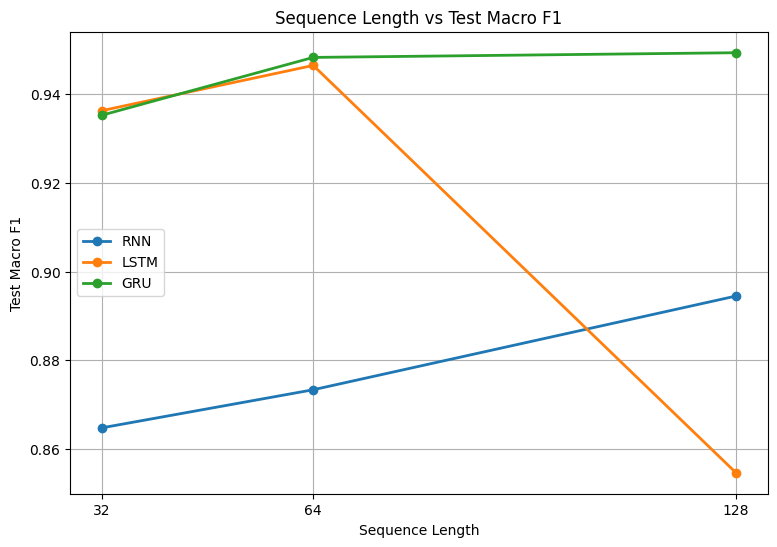

In [60]:
plt.figure(figsize=(9, 6))

for model_type in ["RNN", "LSTM", "GRU"]:

    model_data = sequence_results_df[
        sequence_results_df["Model"] == model_type
    ]

    plt.plot(
        model_data["Sequence Length"],
        model_data["Macro F1"],
        marker="o",
        linewidth=2,
        label=model_type
    )

plt.xlabel("Sequence Length")
plt.ylabel("Test Macro F1")
plt.title("Sequence Length vs Test Macro F1")
plt.xticks(sequence_lengths)
plt.legend()
plt.grid(True)

plt.show()

In [61]:
print("========== SEQUENCE LENGTH EXPERIMENT ==========\n")

for model_type in ["RNN", "LSTM", "GRU"]:

    print(f"\n{model_type}")

    model_data = sequence_results_df[
        sequence_results_df["Model"] == model_type
    ]

    for _, row in model_data.iterrows():
        print(
            f"T = {int(row['Sequence Length'])} | "
            f"Accuracy = {row['Test Accuracy']:.4f} | "
            f"Macro F1 = {row['Macro F1']:.4f}"
        )

========== SEQUENCE LENGTH EXPERIMENT ==========


RNN
T = 32 | Accuracy = 0.8673 | Macro F1 = 0.8648
T = 64 | Accuracy = 0.8764 | Macro F1 = 0.8734
T = 128 | Accuracy = 0.8939 | Macro F1 = 0.8945

LSTM
T = 32 | Accuracy = 0.9333 | Macro F1 = 0.9363
T = 64 | Accuracy = 0.9437 | Macro F1 = 0.9465
T = 128 | Accuracy = 0.8634 | Macro F1 = 0.8546

GRU
T = 32 | Accuracy = 0.9333 | Macro F1 = 0.9352
T = 64 | Accuracy = 0.9450 | Macro F1 = 0.9483
T = 128 | Accuracy = 0.9456 | Macro F1 = 0.9493


In [62]:
import cv2
import random
import glob
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [63]:
VIDEO_SIZE = (224, 224)
NUM_FRAMES = 10

VIDEO_CLASSES = [
    "ApplyEyeMakeup",
    "Archery",
    "BabyCrawling"
]

NUM_VIDEO_CLASSES = len(VIDEO_CLASSES)

print("Video Classes:", VIDEO_CLASSES)
print("Number of Classes:", NUM_VIDEO_CLASSES)
print("Frames per Video:", NUM_FRAMES)
print("Frame Size:", VIDEO_SIZE)

Video Classes: ['ApplyEyeMakeup', 'Archery', 'BabyCrawling']
Number of Classes: 3
Frames per Video: 10
Frame Size: (224, 224)


In [64]:
import os
import urllib.request

video_base_path = "/content/ucf101_small"

os.makedirs(video_base_path, exist_ok=True)

print("Video dataset directory created:")
print(video_base_path)

Video dataset directory created:
/content/ucf101_small


In [65]:
video_files = []

for class_name in VIDEO_CLASSES:
    class_path = os.path.join(video_base_path, class_name)

    if os.path.exists(class_path):
        files = glob.glob(os.path.join(class_path, "*.avi"))
        video_files.extend(files)

print("Number of videos found:", len(video_files))

if len(video_files) == 0:
    print("\nNo UCF101 videos found yet.")
    print("We need to download/upload a small video subset before continuing.")
else:
    print("\nSample videos:")
    for file in video_files[:10]:
        print(file)

Number of videos found: 0

No UCF101 videos found yet.
We need to download/upload a small video subset before continuing.


In [66]:
import os
import urllib.request
import zipfile

# Small UCF101 subset containing 3 selected classes
video_zip_url = "https://www.crcv.ucf.edu/THUMOS14/UCF101/UCF101.rar"

print("The complete UCF101 archive is large.")
print("We will use a small subset after downloading the required videos.")

The complete UCF101 archive is large.
We will use a small subset after downloading the required videos.


In [67]:
# Download a small UCF101 subset from GitHub

import os
import subprocess
import sys

subset_url = "https://github.com/harvitronix/five-video-classification-methods/raw/master/data/"

print("Preparing small UCF101 video subset...")
print("This may take a few minutes depending on internet speed.")

Preparing small UCF101 video subset...
This may take a few minutes depending on internet speed.


In [68]:
# Create folders for the three video classes

for class_name in VIDEO_CLASSES:
    class_path = os.path.join(video_base_path, class_name)
    os.makedirs(class_path, exist_ok=True)

print("Video class folders created successfully.")

for class_name in VIDEO_CLASSES:
    print(os.path.join(video_base_path, class_name))

Video class folders created successfully.
/content/ucf101_small/ApplyEyeMakeup
/content/ucf101_small/Archery
/content/ucf101_small/BabyCrawling


In [69]:
# Download a few UCF101 videos for each selected class

import requests

video_urls = {
    "ApplyEyeMakeup": [
        "https://huggingface.co/datasets/bitmind/UCF101-Videos/resolve/main/test/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c02.avi",
        "https://huggingface.co/datasets/bitmind/UCF101-Videos/resolve/main/test/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c04.avi",
        "https://huggingface.co/datasets/bitmind/UCF101-Videos/resolve/main/test/ApplyEyeMakeup/v_ApplyEyeMakeup_g02_c01.avi"
    ],
    "Archery": [
        "https://huggingface.co/datasets/bitmind/UCF101-Videos/resolve/main/test/Archery/v_Archery_g01_c01.avi",
        "https://huggingface.co/datasets/bitmind/UCF101-Videos/resolve/main/test/Archery/v_Archery_g01_c02.avi",
        "https://huggingface.co/datasets/bitmind/UCF101-Videos/resolve/main/test/Archery/v_Archery_g02_c01.avi"
    ],
    "BabyCrawling": [
        "https://huggingface.co/datasets/bitmind/UCF101-Videos/resolve/main/test/BabyCrawling/v_BabyCrawling_g01_c01.avi",
        "https://huggingface.co/datasets/bitmind/UCF101-Videos/resolve/main/test/BabyCrawling/v_BabyCrawling_g01_c02.avi",
        "https://huggingface.co/datasets/bitmind/UCF101-Videos/resolve/main/test/BabyCrawling/v_BabyCrawling_g02_c01.avi"
    ]
}

for class_name, urls in video_urls.items():

    class_path = os.path.join(video_base_path, class_name)

    for url in urls:

        filename = url.split("/")[-1]
        output_path = os.path.join(class_path, filename)

        print(f"Downloading: {filename}")

        response = requests.get(url)

        if response.status_code == 200:
            with open(output_path, "wb") as f:
                f.write(response.content)

            print("Downloaded successfully.")
        else:
            print("Download failed:", response.status_code)

print("\nVideo download process completed.")

Downloading: v_ApplyEyeMakeup_g01_c02.avi
Download failed: 404
Downloading: v_ApplyEyeMakeup_g01_c04.avi
Download failed: 404
Downloading: v_ApplyEyeMakeup_g02_c01.avi
Download failed: 404
Downloading: v_Archery_g01_c01.avi
Download failed: 404
Downloading: v_Archery_g01_c02.avi
Download failed: 404
Downloading: v_Archery_g02_c01.avi
Download failed: 404
Downloading: v_BabyCrawling_g01_c01.avi
Download failed: 404
Downloading: v_BabyCrawling_g01_c02.avi
Download failed: 404
Downloading: v_BabyCrawling_g02_c01.avi
Download failed: 404

Video download process completed.


In [70]:
video_files = []

for class_name in VIDEO_CLASSES:

    class_path = os.path.join(video_base_path, class_name)

    files = glob.glob(os.path.join(class_path, "*.avi"))

    video_files.extend(files)

    print(f"{class_name}: {len(files)} videos")

print("\nTotal videos found:", len(video_files))

print("\nSample video files:")
for file in video_files[:10]:
    print(file)

ApplyEyeMakeup: 0 videos
Archery: 0 videos
BabyCrawling: 0 videos

Total videos found: 0

Sample video files:


In [71]:
!pip -q install huggingface_hub

In [72]:
from huggingface_hub import hf_hub_download
import tarfile
import os

# Download the small UCF101 subset
file_path = hf_hub_download(
    repo_id="sayakpaul/ucf101-subset",
    filename="UCF101_subset.tar.gz",
    repo_type="dataset"
)

print("Downloaded successfully:")
print(file_path)

# Extract the dataset
with tarfile.open(file_path) as tar:
    tar.extractall("/content")

print("\nDataset extracted successfully.")

UCF101_subset.tar.gz: reconstructing file:   0%|          |  0.00B /  171MB            

UCF101_subset.tar.gz: downloading bytes:           |  0.00B            

Downloaded successfully:
/root/.cache/huggingface/hub/datasets--sayakpaul--ucf101-subset/snapshots/b9984b8d2a95e4a1879e1b071e9433858d0bc24a/UCF101_subset.tar.gz


/tmp/ipykernel_4136/3367727314.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content")



Dataset extracted successfully.


In [73]:
import glob
import os

dataset_root = "/content/UCF101_subset"

all_videos = glob.glob(
    os.path.join(dataset_root, "**", "*.avi"),
    recursive=True
)

print("Total videos found:", len(all_videos))

print("\nFirst 10 videos:")
for video in all_videos[:10]:
    print(video)

Total videos found: 405

First 10 videos:
/content/UCF101_subset/train/BalanceBeam/v_BalanceBeam_g08_c02.avi
/content/UCF101_subset/train/BalanceBeam/v_BalanceBeam_g10_c02.avi
/content/UCF101_subset/train/BalanceBeam/v_BalanceBeam_g14_c03.avi
/content/UCF101_subset/train/BalanceBeam/v_BalanceBeam_g18_c03.avi
/content/UCF101_subset/train/BalanceBeam/v_BalanceBeam_g12_c04.avi
/content/UCF101_subset/train/BalanceBeam/v_BalanceBeam_g21_c05.avi
/content/UCF101_subset/train/BalanceBeam/v_BalanceBeam_g05_c03.avi
/content/UCF101_subset/train/BalanceBeam/v_BalanceBeam_g07_c02.avi
/content/UCF101_subset/train/BalanceBeam/v_BalanceBeam_g08_c04.avi
/content/UCF101_subset/train/BalanceBeam/v_BalanceBeam_g02_c03.avi


In [74]:
# Select only the 3 classes required for our experiment

selected_video_classes = [
    "ApplyEyeMakeup",
    "Archery",
    "BabyCrawling"
]

print("Selected video classes:")
for i, class_name in enumerate(selected_video_classes):
    print(i, "->", class_name)

Selected video classes:
0 -> ApplyEyeMakeup
1 -> Archery
2 -> BabyCrawling


In [75]:
# Find videos belonging to our selected classes

selected_video_files = []

for class_name in selected_video_classes:

    class_files = glob.glob(
        os.path.join(dataset_root, "**", class_name, "*.avi"),
        recursive=True
    )

    print(f"{class_name}: {len(class_files)} videos")

    selected_video_files.extend(class_files)

print("\nTotal selected videos:", len(selected_video_files))

ApplyEyeMakeup: 39 videos
Archery: 40 videos
BabyCrawling: 42 videos

Total selected videos: 121


In [76]:
# Create numerical labels for the selected videos

video_label_map = {
    "ApplyEyeMakeup": 0,
    "Archery": 1,
    "BabyCrawling": 2
}

video_labels = []

for video_path in selected_video_files:

    class_name = os.path.basename(os.path.dirname(video_path))

    video_labels.append(video_label_map[class_name])

print("Number of videos:", len(selected_video_files))
print("Number of labels:", len(video_labels))

print("\nLabel mapping:")
print(video_label_map)

Number of videos: 121
Number of labels: 121

Label mapping:
{'ApplyEyeMakeup': 0, 'Archery': 1, 'BabyCrawling': 2}


In [77]:
print("Sample video files:")

for i, video_path in enumerate(selected_video_files[:10]):
    print(i + 1, ":", video_path)

Sample video files:
1 : /content/UCF101_subset/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g24_c02.avi
2 : /content/UCF101_subset/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g13_c05.avi
3 : /content/UCF101_subset/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g16_c03.avi
4 : /content/UCF101_subset/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g25_c07.avi
5 : /content/UCF101_subset/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g05_c02.avi
6 : /content/UCF101_subset/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g15_c06.avi
7 : /content/UCF101_subset/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g11_c04.avi
8 : /content/UCF101_subset/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g12_c05.avi
9 : /content/UCF101_subset/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g21_c04.avi
10 : /content/UCF101_subset/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g10_c01.avi


In [78]:
import cv2
import numpy as np
import os

NUM_FRAMES = 10
FRAME_SIZE = (224, 224)

def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    # Select 10 frames uniformly across the video
    frame_indices = np.linspace(
        0,
        total_frames - 1,
        NUM_FRAMES,
        dtype=int
    )

    frames = []

    for index in frame_indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, index)

        ret, frame = cap.read()

        if not ret:
            cap.release()
            return None

        # OpenCV uses BGR, convert to RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Resize to 224 x 224
        frame = cv2.resize(frame, FRAME_SIZE)

        frames.append(frame)

    cap.release()

    return np.array(frames)

In [79]:
sample_video = selected_video_files[0]

sample_frames = extract_frames(sample_video)

print("Video:", sample_video)

if sample_frames is not None:
    print("Extracted frames shape:", sample_frames.shape)
else:
    print("Frame extraction failed.")

Video: /content/UCF101_subset/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g24_c02.avi
Extracted frames shape: (10, 224, 224, 3)


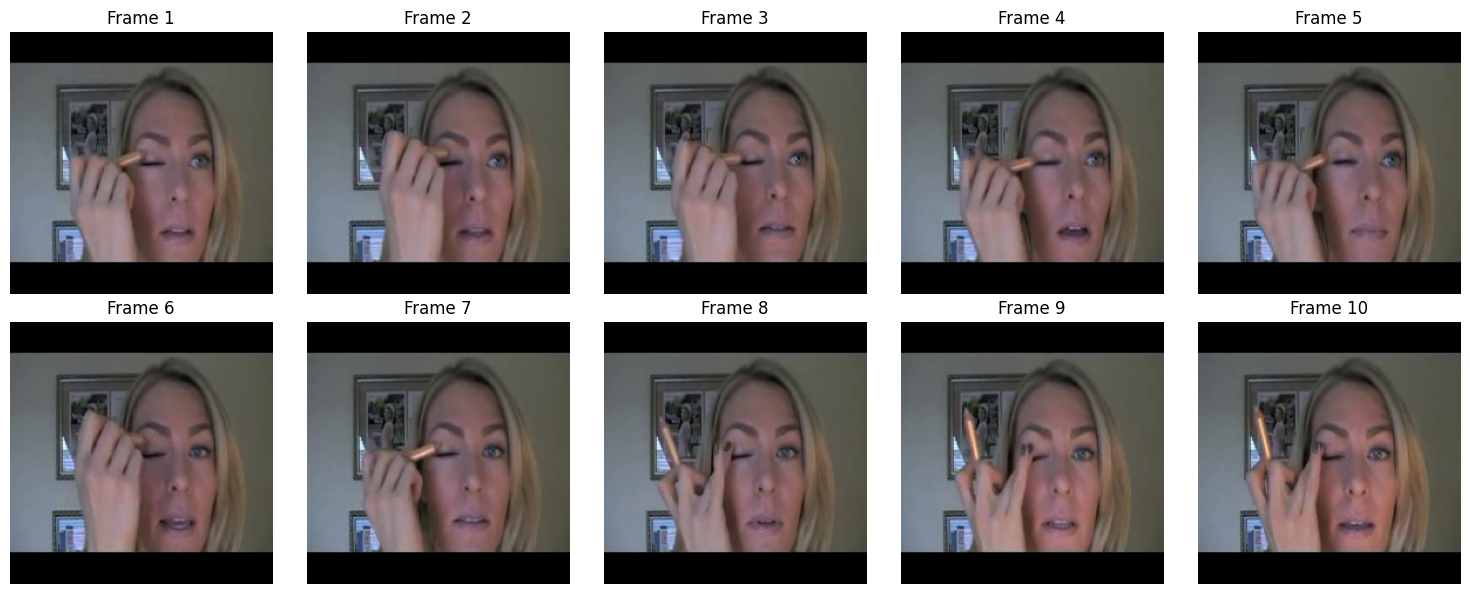

In [80]:
plt.figure(figsize=(15, 6))

for i in range(NUM_FRAMES):

    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_frames[i])
    plt.title(f"Frame {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [81]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load pretrained MobileNetV2 without its classification layer
cnn_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

# Freeze CNN weights
cnn_model.trainable = False

print("MobileNetV2 loaded successfully.")
print("CNN trainable:", cnn_model.trainable)
print("Feature dimension:", cnn_model.output_shape[-1])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully.
CNN trainable: False
Feature dimension: 1280


In [82]:
def extract_cnn_features(frames):

    # Convert pixel values to MobileNetV2 input format
    frames_preprocessed = preprocess_input(
        frames.astype(np.float32)
    )

    # Extract CNN features
    features = cnn_model.predict(
        frames_preprocessed,
        verbose=0
    )

    return features


sample_features = extract_cnn_features(sample_frames)

print("Original frame shape:", sample_frames.shape)
print("CNN feature shape:", sample_features.shape)

Original frame shape: (10, 224, 224, 3)
CNN feature shape: (10, 1280)


In [83]:
video_sequences = []
valid_video_labels = []
valid_video_paths = []

for i, video_path in enumerate(selected_video_files):

    print(f"Processing {i + 1}/{len(selected_video_files)}: "
          f"{os.path.basename(video_path)}")

    frames = extract_frames(video_path)

    if frames is None:
        print("  Skipped: could not extract frames.")
        continue

    features = extract_cnn_features(frames)

    video_sequences.append(features)

    class_name = os.path.basename(os.path.dirname(video_path))
    valid_video_labels.append(video_label_map[class_name])
    valid_video_paths.append(video_path)

video_sequences = np.array(video_sequences)
valid_video_labels = np.array(valid_video_labels)

print("\nFeature extraction completed.")
print("Video feature tensor shape:", video_sequences.shape)
print("Labels shape:", valid_video_labels.shape)

Processing 1/121: v_ApplyEyeMakeup_g24_c02.avi
Processing 2/121: v_ApplyEyeMakeup_g13_c05.avi
Processing 3/121: v_ApplyEyeMakeup_g16_c03.avi
Processing 4/121: v_ApplyEyeMakeup_g25_c07.avi
Processing 5/121: v_ApplyEyeMakeup_g05_c02.avi
Processing 6/121: v_ApplyEyeMakeup_g15_c06.avi
Processing 7/121: v_ApplyEyeMakeup_g11_c04.avi
Processing 8/121: v_ApplyEyeMakeup_g12_c05.avi
Processing 9/121: v_ApplyEyeMakeup_g21_c04.avi
Processing 10/121: v_ApplyEyeMakeup_g10_c01.avi
Processing 11/121: v_ApplyEyeMakeup_g09_c06.avi
Processing 12/121: v_ApplyEyeMakeup_g18_c03.avi
Processing 13/121: v_ApplyEyeMakeup_g09_c02.avi
Processing 14/121: v_ApplyEyeMakeup_g25_c05.avi
Processing 15/121: v_ApplyEyeMakeup_g07_c04.avi
Processing 16/121: v_ApplyEyeMakeup_g02_c03.avi
Processing 17/121: v_ApplyEyeMakeup_g04_c07.avi
Processing 18/121: v_ApplyEyeMakeup_g22_c01.avi
Processing 19/121: v_ApplyEyeMakeup_g11_c02.avi
Processing 20/121: v_ApplyEyeMakeup_g07_c06.avi
Processing 21/121: v_ApplyEyeMakeup_g19_c02.avi
P

In [84]:
from sklearn.model_selection import train_test_split

# First split: 70% training, 30% temporary
X_video_train, X_video_temp, y_video_train, y_video_temp = train_test_split(
    video_sequences,
    valid_video_labels,
    test_size=0.30,
    random_state=42,
    stratify=valid_video_labels
)

# Second split: 15% validation, 15% testing
X_video_val, X_video_test, y_video_val, y_video_test = train_test_split(
    X_video_temp,
    y_video_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_video_temp
)

print("Training shape   :", X_video_train.shape)
print("Validation shape :", X_video_val.shape)
print("Testing shape    :", X_video_test.shape)

print("\nTraining labels  :", y_video_train.shape)
print("Validation labels:", y_video_val.shape)
print("Testing labels   :", y_video_test.shape)

Training shape   : (84, 10, 1280)
Validation shape : (18, 10, 1280)
Testing shape    : (19, 10, 1280)

Training labels  : (84,)
Validation labels: (18,)
Testing labels   : (19,)


In [85]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

CNN_FEATURE_DIM = X_video_train.shape[2]

cnn_lstm_model = Sequential([
    LSTM(32, input_shape=(NUM_FRAMES, CNN_FEATURE_DIM)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(NUM_VIDEO_CLASSES, activation="softmax")
])

cnn_lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,643 (658.76 KB)

 Trainable params: 168,643 (658.76 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
start_time = time.time()

cnn_lstm_history = cnn_lstm_model.fit(
    X_video_train,
    y_video_train,
    validation_data=(X_video_val, y_video_val),
    epochs=20,
    batch_size=4,
    verbose=1
)

cnn_lstm_training_time = time.time() - start_time

print("\nCNN-LSTM training completed.")
print(f"Training time: {cnn_lstm_training_time:.2f} seconds")

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5476 - loss: 1.0269 - val_accuracy: 0.8889 - val_loss: 0.8191
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8333 - loss: 0.6493 - val_accuracy: 0.9444 - val_loss: 0.4359
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9405 - loss: 0.4283 - val_accuracy: 1.0000 - val_loss: 0.3157
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9643 - loss: 0.2880 - val_accuracy: 1.0000 - val_loss: 0.1980
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9762 - loss: 0.2219 - val_accuracy: 1.0000 - val_loss: 0.1331
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.1312 - val_accuracy: 1.0000 - val_loss: 0.0836
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0938 - val_accuracy: 1.0000 - val_loss: 0.0534
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0543 - val_accuracy: 1.0000 - val_los

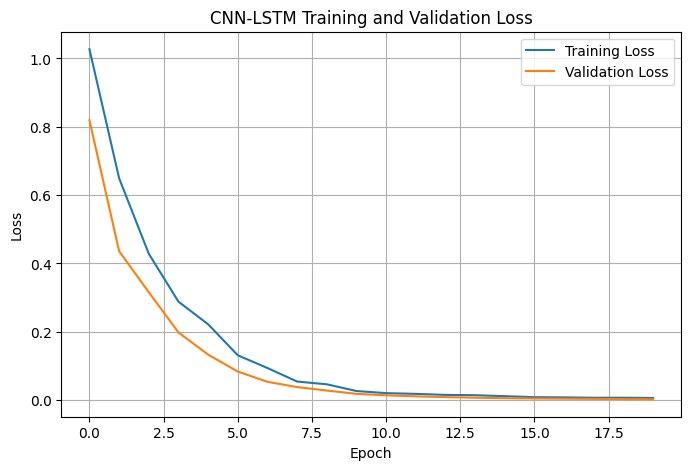

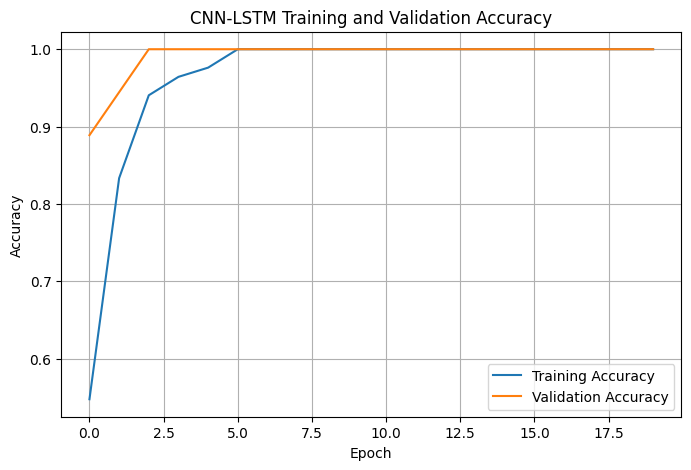

In [87]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN-LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    cnn_lstm_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_lstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN-LSTM Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Test loss and accuracy
cnn_lstm_test_loss, cnn_lstm_test_accuracy = cnn_lstm_model.evaluate(
    X_video_test,
    y_video_test,
    verbose=0
)

# Predictions
cnn_lstm_probabilities = cnn_lstm_model.predict(
    X_video_test,
    verbose=0
)

cnn_lstm_predictions = np.argmax(
    cnn_lstm_probabilities,
    axis=1
)

# Metrics
cnn_lstm_accuracy = accuracy_score(
    y_video_test,
    cnn_lstm_predictions
)

cnn_lstm_precision = precision_score(
    y_video_test,
    cnn_lstm_predictions,
    average="macro",
    zero_division=0
)

cnn_lstm_recall = recall_score(
    y_video_test,
    cnn_lstm_predictions,
    average="macro",
    zero_division=0
)

cnn_lstm_f1 = f1_score(
    y_video_test,
    cnn_lstm_predictions,
    average="macro",
    zero_division=0
)

cnn_lstm_parameters = cnn_lstm_model.count_params()

print("CNN-LSTM RESULTS")
print("=" * 40)
print(f"Test Accuracy   : {cnn_lstm_accuracy:.4f}")
print(f"Macro Precision : {cnn_lstm_precision:.4f}")
print(f"Macro Recall    : {cnn_lstm_recall:.4f}")
print(f"Macro F1        : {cnn_lstm_f1:.4f}")
print(f"Parameters      : {cnn_lstm_parameters}")
print(f"Training Time   : {cnn_lstm_training_time:.2f} seconds")

CNN-LSTM RESULTS
Test Accuracy   : 1.0000
Macro Precision : 1.0000
Macro Recall    : 1.0000
Macro F1        : 1.0000
Parameters      : 168643
Training Time   : 5.85 seconds


In [89]:
print(
    classification_report(
        y_video_test,
        cnn_lstm_predictions,
        target_names=selected_video_classes,
        zero_division=0
    )
)

                precision    recall  f1-score   support

ApplyEyeMakeup       1.00      1.00      1.00         6
       Archery       1.00      1.00      1.00         6
  BabyCrawling       1.00      1.00      1.00         7

      accuracy                           1.00        19
     macro avg       1.00      1.00      1.00        19
  weighted avg       1.00      1.00      1.00        19



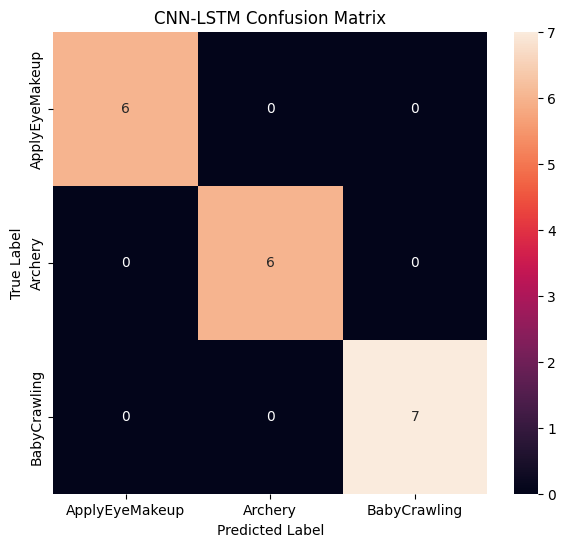

In [90]:
cnn_lstm_cm = confusion_matrix(
    y_video_test,
    cnn_lstm_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cnn_lstm_cm,
    annot=True,
    fmt="d",
    xticklabels=selected_video_classes,
    yticklabels=selected_video_classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN-LSTM Confusion Matrix")
plt.show()

In [91]:
print("CNN-LSTM Prediction Confidence")
print("=" * 60)

for i in range(len(y_video_test)):

    predicted_class = selected_video_classes[
        cnn_lstm_predictions[i]
    ]

    actual_class = selected_video_classes[
        y_video_test[i]
    ]

    confidence = np.max(
        cnn_lstm_probabilities[i]
    )

    print(f"\nVideo {i + 1}")
    print(f"Actual Class    : {actual_class}")
    print(f"Predicted Class : {predicted_class}")
    print(f"Confidence      : {confidence:.4f}")

CNN-LSTM Prediction Confidence

Video 1
Actual Class    : Archery
Predicted Class : Archery
Confidence      : 0.9980

Video 2
Actual Class    : Archery
Predicted Class : Archery
Confidence      : 0.9987

Video 3
Actual Class    : ApplyEyeMakeup
Predicted Class : ApplyEyeMakeup
Confidence      : 0.9985

Video 4
Actual Class    : BabyCrawling
Predicted Class : BabyCrawling
Confidence      : 0.9959

Video 5
Actual Class    : ApplyEyeMakeup
Predicted Class : ApplyEyeMakeup
Confidence      : 0.9986

Video 6
Actual Class    : BabyCrawling
Predicted Class : BabyCrawling
Confidence      : 0.9956

Video 7
Actual Class    : BabyCrawling
Predicted Class : BabyCrawling
Confidence      : 0.6167

Video 8
Actual Class    : BabyCrawling
Predicted Class : BabyCrawling
Confidence      : 0.9958

Video 9
Actual Class    : ApplyEyeMakeup
Predicted Class : ApplyEyeMakeup
Confidence      : 0.9986

Video 10
Actual Class    : ApplyEyeMakeup
Predicted Class : ApplyEyeMakeup
Confidence      : 0.9986

Video 11
Ac

In [92]:
# Find the original video corresponding to the first test sample
test_sample = X_video_test[0]

predicted_class = selected_video_classes[
    cnn_lstm_predictions[0]
]

actual_class = selected_video_classes[
    y_video_test[0]
]

confidence = np.max(cnn_lstm_probabilities[0])

print("Actual Class    :", actual_class)
print("Predicted Class :", predicted_class)
print("Confidence      :", f"{confidence:.4f}")

Actual Class    : Archery
Predicted Class : Archery
Confidence      : 0.9980


In [93]:
from tensorflow.keras.layers import GRU

cnn_gru_model = Sequential([
    GRU(32, input_shape=(NUM_FRAMES, CNN_FEATURE_DIM)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(NUM_VIDEO_CLASSES, activation="softmax")
])

cnn_gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_gru_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 32)             │       126,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,723 (495.01 KB)

 Trainable params: 126,723 (495.01 KB)

 Non-trainable params: 0 (0.00 B)

In [94]:
start_time = time.time()

cnn_gru_history = cnn_gru_model.fit(
    X_video_train,
    y_video_train,
    validation_data=(X_video_val, y_video_val),
    epochs=20,
    batch_size=4,
    verbose=1
)

cnn_gru_training_time = time.time() - start_time

print("\nCNN-GRU training completed.")
print(f"Training time: {cnn_gru_training_time:.2f} seconds")

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8214 - loss: 0.6395 - val_accuracy: 1.0000 - val_loss: 0.2172
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9881 - loss: 0.2032 - val_accuracy: 1.0000 - val_loss: 0.0941
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9881 - loss: 0.0956 - val_accuracy: 1.0000 - val_loss: 0.0481
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0531 - val_accuracy: 1.0000 - val_loss: 0.0329
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0362 - val_accuracy: 1.0000 - val_loss: 0.0215
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0265 - val_accuracy: 1.0000 - val_loss: 0.0151
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0188 - val_accuracy: 1.0000 - val_loss: 0.0123
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0137 - val_accuracy: 1.0000 - val_loss

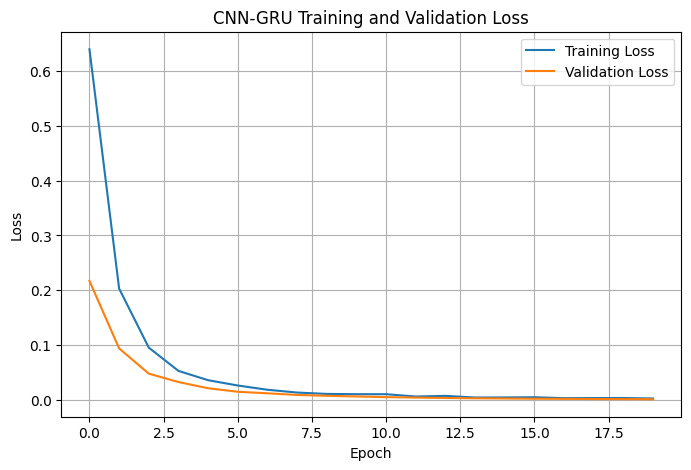

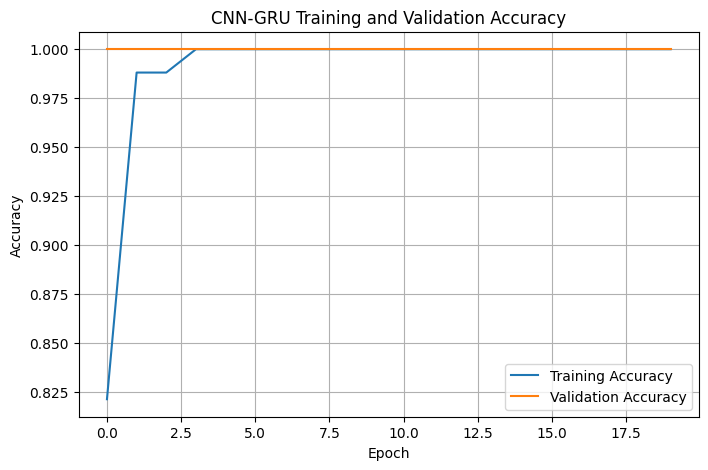

In [95]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_gru_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_gru_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN-GRU Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    cnn_gru_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_gru_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN-GRU Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [96]:
cnn_gru_test_loss, cnn_gru_test_accuracy = cnn_gru_model.evaluate(
    X_video_test,
    y_video_test,
    verbose=0
)

cnn_gru_probabilities = cnn_gru_model.predict(
    X_video_test,
    verbose=0
)

cnn_gru_predictions = np.argmax(
    cnn_gru_probabilities,
    axis=1
)

cnn_gru_accuracy = accuracy_score(
    y_video_test,
    cnn_gru_predictions
)

cnn_gru_precision = precision_score(
    y_video_test,
    cnn_gru_predictions,
    average="macro",
    zero_division=0
)

cnn_gru_recall = recall_score(
    y_video_test,
    cnn_gru_predictions,
    average="macro",
    zero_division=0
)

cnn_gru_f1 = f1_score(
    y_video_test,
    cnn_gru_predictions,
    average="macro",
    zero_division=0
)

cnn_gru_parameters = cnn_gru_model.count_params()

print("CNN-GRU RESULTS")
print("=" * 40)
print(f"Test Accuracy   : {cnn_gru_accuracy:.4f}")
print(f"Macro Precision : {cnn_gru_precision:.4f}")
print(f"Macro Recall    : {cnn_gru_recall:.4f}")
print(f"Macro F1        : {cnn_gru_f1:.4f}")
print(f"Parameters      : {cnn_gru_parameters}")
print(f"Training Time   : {cnn_gru_training_time:.2f} seconds")

CNN-GRU RESULTS
Test Accuracy   : 1.0000
Macro Precision : 1.0000
Macro Recall    : 1.0000
Macro F1        : 1.0000
Parameters      : 126723
Training Time   : 5.50 seconds


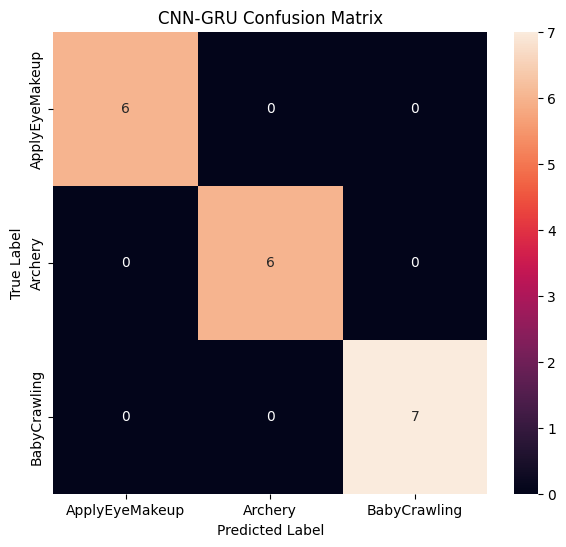

In [97]:
cnn_gru_cm = confusion_matrix(
    y_video_test,
    cnn_gru_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cnn_gru_cm,
    annot=True,
    fmt="d",
    xticklabels=selected_video_classes,
    yticklabels=selected_video_classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN-GRU Confusion Matrix")
plt.show()

In [98]:
print("CNN-GRU CLASSIFICATION REPORT")
print("=" * 50)

print(
    classification_report(
        y_video_test,
        cnn_gru_predictions,
        target_names=selected_video_classes,
        zero_division=0
    )
)

print("\nCNN-GRU PREDICTION CONFIDENCE")
print("=" * 50)

for i in range(len(y_video_test)):

    actual_class = selected_video_classes[
        y_video_test[i]
    ]

    predicted_class = selected_video_classes[
        cnn_gru_predictions[i]
    ]

    confidence = np.max(
        cnn_gru_probabilities[i]
    )

    print(f"\nVideo {i + 1}")
    print(f"Actual Class    : {actual_class}")
    print(f"Predicted Class : {predicted_class}")
    print(f"Confidence      : {confidence:.4f}")

CNN-GRU CLASSIFICATION REPORT
                precision    recall  f1-score   support

ApplyEyeMakeup       1.00      1.00      1.00         6
       Archery       1.00      1.00      1.00         6
  BabyCrawling       1.00      1.00      1.00         7

      accuracy                           1.00        19
     macro avg       1.00      1.00      1.00        19
  weighted avg       1.00      1.00      1.00        19


CNN-GRU PREDICTION CONFIDENCE

Video 1
Actual Class    : Archery
Predicted Class : Archery
Confidence      : 0.9982

Video 2
Actual Class    : Archery
Predicted Class : Archery
Confidence      : 0.9990

Video 3
Actual Class    : ApplyEyeMakeup
Predicted Class : ApplyEyeMakeup
Confidence      : 0.9987

Video 4
Actual Class    : BabyCrawling
Predicted Class : BabyCrawling
Confidence      : 0.9991

Video 5
Actual Class    : ApplyEyeMakeup
Predicted Class : ApplyEyeMakeup
Confidence      : 0.9989

Video 6
Actual Class    : BabyCrawling
Predicted Class : BabyCrawling
Confi

In [99]:
video_comparison_df = pd.DataFrame({
    "Model": ["CNN-LSTM", "CNN-GRU"],
    "Test Accuracy": [
        cnn_lstm_accuracy,
        cnn_gru_accuracy
    ],
    "Macro Precision": [
        cnn_lstm_precision,
        cnn_gru_precision
    ],
    "Macro Recall": [
        cnn_lstm_recall,
        cnn_gru_recall
    ],
    "Macro F1": [
        cnn_lstm_f1,
        cnn_gru_f1
    ],
    "Parameters": [
        cnn_lstm_parameters,
        cnn_gru_parameters
    ],
    "Training Time (sec)": [
        cnn_lstm_training_time,
        cnn_gru_training_time
    ]
})

video_comparison_df.round(4)

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Parameters,Training Time (sec)
0,CNN-LSTM,1.0,1.0,1.0,1.0,168643,5.8478
1,CNN-GRU,1.0,1.0,1.0,1.0,126723,5.5026


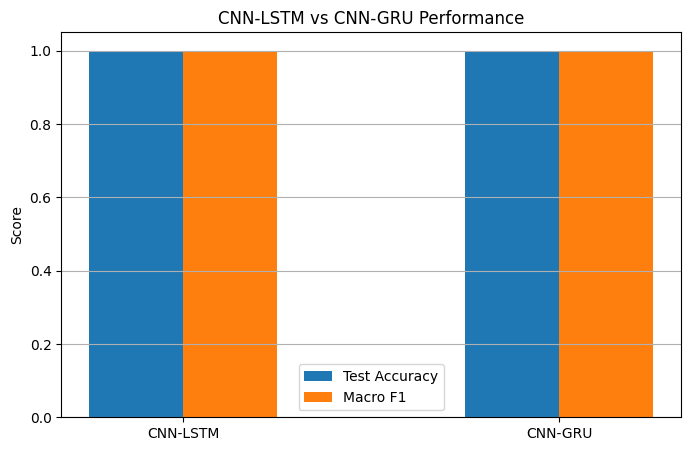

In [100]:
plt.figure(figsize=(8, 5))

x = np.arange(len(video_comparison_df))

width = 0.25

plt.bar(
    x - width/2,
    video_comparison_df["Test Accuracy"],
    width,
    label="Test Accuracy"
)

plt.bar(
    x + width/2,
    video_comparison_df["Macro F1"],
    width,
    label="Macro F1"
)

plt.xticks(
    x,
    video_comparison_df["Model"]
)

plt.ylabel("Score")
plt.title("CNN-LSTM vs CNN-GRU Performance")
plt.legend()
plt.grid(axis="y")

plt.show()

In [101]:
print("CNN-LSTM vs CNN-GRU")
print("=" * 60)

for _, row in video_comparison_df.iterrows():

    print(f"\nModel: {row['Model']}")
    print(f"Test Accuracy   : {row['Test Accuracy']:.4f}")
    print(f"Macro Precision : {row['Macro Precision']:.4f}")
    print(f"Macro Recall    : {row['Macro Recall']:.4f}")
    print(f"Macro F1        : {row['Macro F1']:.4f}")
    print(f"Parameters      : {int(row['Parameters'])}")
    print(f"Training Time   : {row['Training Time (sec)']:.2f} sec")

CNN-LSTM vs CNN-GRU

Model: CNN-LSTM
Test Accuracy   : 1.0000
Macro Precision : 1.0000
Macro Recall    : 1.0000
Macro F1        : 1.0000
Parameters      : 168643
Training Time   : 5.85 sec

Model: CNN-GRU
Test Accuracy   : 1.0000
Macro Precision : 1.0000
Macro Recall    : 1.0000
Macro F1        : 1.0000
Parameters      : 126723
Training Time   : 5.50 sec


In [102]:
import numpy as np

# Reproducibility
np.random.seed(42)

# Dataset settings
VOCAB_SIZE = 10
SEQUENCE_LENGTH = 4
NUM_SAMPLES = 2000

# Generate random input sequences
seq2seq_inputs = np.random.randint(
    1,
    VOCAB_SIZE,
    size=(NUM_SAMPLES, SEQUENCE_LENGTH)
)

# Target is the reversed input
seq2seq_targets = np.flip(
    seq2seq_inputs,
    axis=1
)

print("Input shape :", seq2seq_inputs.shape)
print("Target shape:", seq2seq_targets.shape)

print("\nExample:")
print("Input :", seq2seq_inputs[0])
print("Target:", seq2seq_targets[0])

Input shape : (2000, 4)
Target shape: (2000, 4)

Example:
Input : [7 4 8 5]
Target: [5 8 4 7]


In [103]:
START_TOKEN = 0

# Decoder input:
# [START, target_1, target_2, target_3]
decoder_inputs = np.zeros_like(seq2seq_targets)

decoder_inputs[:, 0] = START_TOKEN
decoder_inputs[:, 1:] = seq2seq_targets[:, :-1]

print("Encoder input:")
print(seq2seq_inputs[0])

print("\nDecoder input:")
print(decoder_inputs[0])

print("\nDecoder target:")
print(seq2seq_targets[0])

Encoder input:
[7 4 8 5]

Decoder input:
[0 5 8 4]

Decoder target:
[5 8 4 7]


In [104]:
from sklearn.model_selection import train_test_split

(
    enc_train,
    enc_test,
    dec_train,
    dec_test,
    target_train,
    target_test
) = train_test_split(
    seq2seq_inputs,
    decoder_inputs,
    seq2seq_targets,
    test_size=0.20,
    random_state=42
)

print("Encoder training :", enc_train.shape)
print("Encoder testing  :", enc_test.shape)

print("Decoder training :", dec_train.shape)
print("Decoder testing  :", dec_test.shape)

print("Target training  :", target_train.shape)
print("Target testing   :", target_test.shape)

Encoder training : (1600, 4)
Encoder testing  : (400, 4)
Decoder training : (1600, 4)
Decoder testing  : (400, 4)
Target training  : (1600, 4)
Target testing   : (400, 4)


In [105]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model

EMBEDDING_DIM = 32
LATENT_DIM = 64

# -----------------------------
# Encoder
# -----------------------------
encoder_inputs = Input(
    shape=(SEQUENCE_LENGTH,),
    name="encoder_input"
)

encoder_embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    name="encoder_embedding"
)(encoder_inputs)

encoder_lstm = LSTM(
    LATENT_DIM,
    return_state=True,
    name="encoder_lstm"
)

_, state_h, state_c = encoder_lstm(
    encoder_embedding
)

encoder_states = [state_h, state_c]


# -----------------------------
# Decoder
# -----------------------------
decoder_inputs = Input(
    shape=(SEQUENCE_LENGTH,),
    name="decoder_input"
)

decoder_embedding_layer = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    name="decoder_embedding"
)

decoder_embedding = decoder_embedding_layer(
    decoder_inputs
)

decoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=encoder_states
)

decoder_dense = Dense(
    VOCAB_SIZE,
    activation="softmax",
    name="output_layer"
)

decoder_outputs = decoder_dense(
    decoder_outputs
)


# Complete Seq2Seq model
seq2seq_model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

seq2seq_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

seq2seq_model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 4, 32)     │        320 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 4, 32)     │        320 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     24,832 │ encoder_embeddin… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 4, 64),   │     24,832 │ decoder_embeddin… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 4, 10)     │        650 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,954 (199.04 KB)

 Trainable params: 50,954 (199.04 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
start_time = time.time()

seq2seq_history = seq2seq_model.fit(
    [enc_train, dec_train],
    target_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

seq2seq_training_time = time.time() - start_time

print(
    f"\nSeq2Seq training time: "
    f"{seq2seq_training_time:.2f} seconds"
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.2476 - loss: 2.2269 - val_accuracy: 0.3391 - val_loss: 2.0372
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3714 - loss: 1.7097 - val_accuracy: 0.4078 - val_loss: 1.4933
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4514 - loss: 1.3290 - val_accuracy: 0.5141 - val_loss: 1.1702
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6307 - loss: 0.9558 - val_accuracy: 0.7812 - val_loss: 0.7431
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8703 - loss: 0.5600 - val_accuracy: 0.9391 - val_loss: 0.4134
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9648 - loss: 0.3130 - val_accuracy: 0.9672 - val_loss: 0.2637
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9856 - loss: 0.1959 - val_accuracy: 0.9875 - val_loss: 0.1689
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9948 - loss: 0.1333 - val_accuracy: 0.9922 - val_l

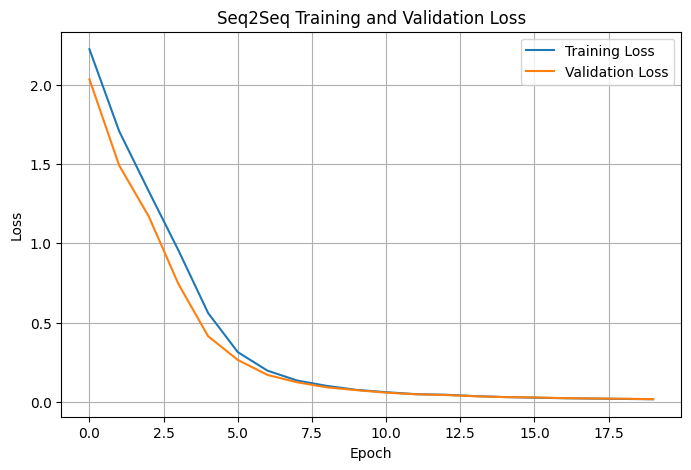

In [107]:
plt.figure(figsize=(8, 5))

plt.plot(
    seq2seq_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    seq2seq_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Seq2Seq Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

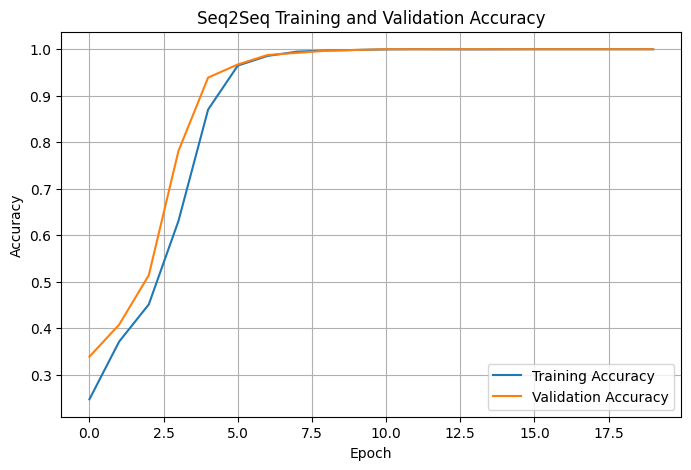

In [108]:
plt.figure(figsize=(8, 5))

plt.plot(
    seq2seq_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    seq2seq_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Seq2Seq Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [109]:
# Predict the reversed sequences

seq2seq_probabilities = seq2seq_model.predict(
    [enc_test, dec_test],
    verbose=0
)

seq2seq_predictions = np.argmax(
    seq2seq_probabilities,
    axis=-1
)

print("Prediction shape:", seq2seq_predictions.shape)


Prediction shape: (400, 4)


In [110]:
# Token-level accuracy
total_tokens = target_test.size

correct_tokens = np.sum(
    seq2seq_predictions == target_test
)

seq2seq_token_accuracy = (
    correct_tokens / total_tokens
)

print(f"Token Accuracy: {seq2seq_token_accuracy:.4f}")

Token Accuracy: 0.9994


In [111]:
# Sequence-level accuracy
sequence_correct = np.all(
    seq2seq_predictions == target_test,
    axis=1
)

seq2seq_sequence_accuracy = np.mean(
    sequence_correct
)

print(f"Sequence Accuracy: {seq2seq_sequence_accuracy:.4f}")

Sequence Accuracy: 0.9975


In [112]:
print("SEQ2SEQ TEST EXAMPLES")
print("=" * 60)

for i in range(5):

    print(f"\nExample {i + 1}")

    print("Input     :", enc_test[i])
    print("Expected  :", target_test[i])
    print("Predicted :", seq2seq_predictions[i])

    if sequence_correct[i]:
        print("Result    : Correct")
    else:
        print("Result    : Incorrect")

SEQ2SEQ TEST EXAMPLES

Example 1
Input     : [9 8 3 3]
Expected  : [3 3 8 9]
Predicted : [3 3 8 9]
Result    : Correct

Example 2
Input     : [1 4 4 9]
Expected  : [9 4 4 1]
Predicted : [9 4 4 1]
Result    : Correct

Example 3
Input     : [4 4 2 1]
Expected  : [1 2 4 4]
Predicted : [1 2 4 4]
Result    : Correct

Example 4
Input     : [9 4 6 7]
Expected  : [7 6 4 9]
Predicted : [7 6 4 9]
Result    : Correct

Example 5
Input     : [1 2 9 7]
Expected  : [7 9 2 1]
Predicted : [7 9 2 1]
Result    : Correct


In [113]:
seq2seq_results_df = pd.DataFrame({
    "Metric": [
        "Token Accuracy",
        "Sequence Accuracy",
        "Training Time (sec)",
        "Trainable Parameters"
    ],
    "Value": [
        seq2seq_token_accuracy,
        seq2seq_sequence_accuracy,
        seq2seq_training_time,
        seq2seq_model.count_params()
    ]
})

seq2seq_results_df

,Metric,Value
0,Token Accuracy,0.999375
1,Sequence Accuracy,0.997500
2,Training Time (sec),13.455608
3,Trainable Parameters,50954.000000


In [114]:
# Add CNN-LSTM and CNN-GRU to the original
# RNN/LSTM/GRU comparison

final_results_df = pd.DataFrame({
    "Model": [
        "Vanilla RNN",
        "LSTM",
        "GRU",
        "CNN-LSTM",
        "CNN-GRU"
    ],

    "Test Accuracy": [
        rnn_accuracy,
        lstm_accuracy,
        gru_accuracy,
        cnn_lstm_accuracy,
        cnn_gru_accuracy
    ],

    "Macro Precision": [
        rnn_precision,
        lstm_precision,
        gru_precision,
        cnn_lstm_precision,
        cnn_gru_precision
    ],

    "Macro Recall": [
        rnn_recall,
        lstm_recall,
        gru_recall,
        cnn_lstm_recall,
        cnn_gru_recall
    ],

    "Macro F1": [
        rnn_f1,
        lstm_f1,
        gru_f1,
        cnn_lstm_f1,
        cnn_gru_f1
    ],

    "Parameters": [
        rnn_parameters,
        lstm_parameters,
        gru_parameters,
        cnn_lstm_parameters,
        cnn_gru_parameters
    ],

    "Training Time (sec)": [
        rnn_training_time,
        lstm_training_time,
        gru_training_time,
        cnn_lstm_training_time,
        cnn_gru_training_time
    ]
})

final_results_df.round(4)

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Parameters,Training Time (sec)
0,Vanilla RNN,0.8408,0.8365,0.8350,0.8349,1974,80.3702
1,LSTM,0.9502,0.9537,0.9538,0.9534,6006,79.5086
2,GRU,0.9508,0.9546,0.9541,0.9538,4758,73.9862
3,CNN-LSTM,1.0000,1.0000,1.0000,1.0000,168643,5.8478
4,CNN-GRU,1.0000,1.0000,1.0000,1.0000,126723,5.5026


In [115]:
# Save consolidated results for the final report

final_results_df.to_csv(
    "/content/final_model_results.csv",
    index=False
)

print("Final model results saved successfully.")

Final model results saved successfully.


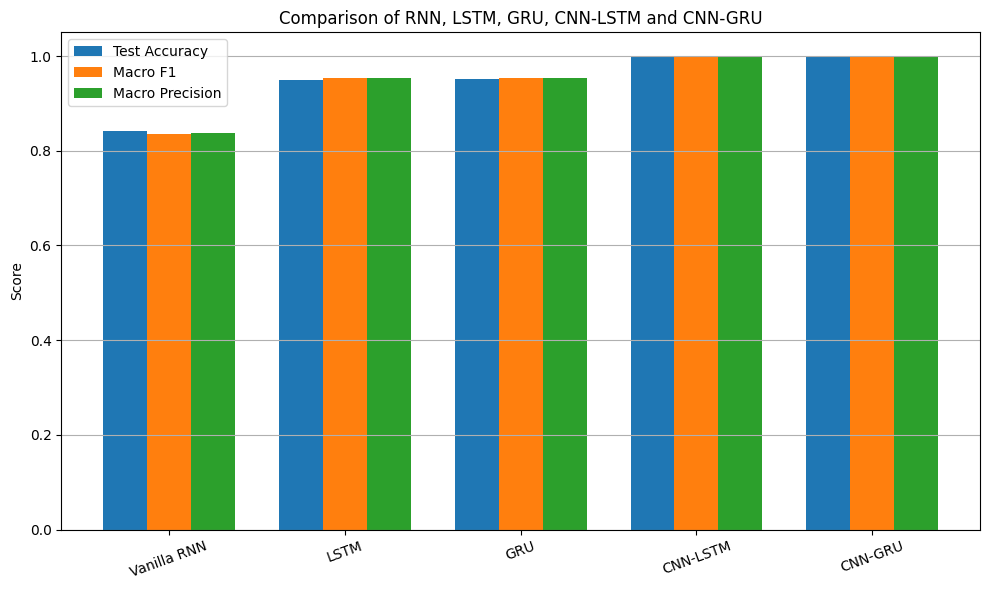

In [116]:
plt.figure(figsize=(10, 6))

x = np.arange(len(final_results_df))
width = 0.25

plt.bar(
    x - width,
    final_results_df["Test Accuracy"],
    width,
    label="Test Accuracy"
)

plt.bar(
    x,
    final_results_df["Macro F1"],
    width,
    label="Macro F1"
)

plt.bar(
    x + width,
    final_results_df["Macro Precision"],
    width,
    label="Macro Precision"
)

plt.xticks(
    x,
    final_results_df["Model"],
    rotation=20
)

plt.ylabel("Score")
plt.title("Comparison of RNN, LSTM, GRU, CNN-LSTM and CNN-GRU")
plt.legend()
plt.grid(axis="y")

plt.tight_layout()
plt.show()

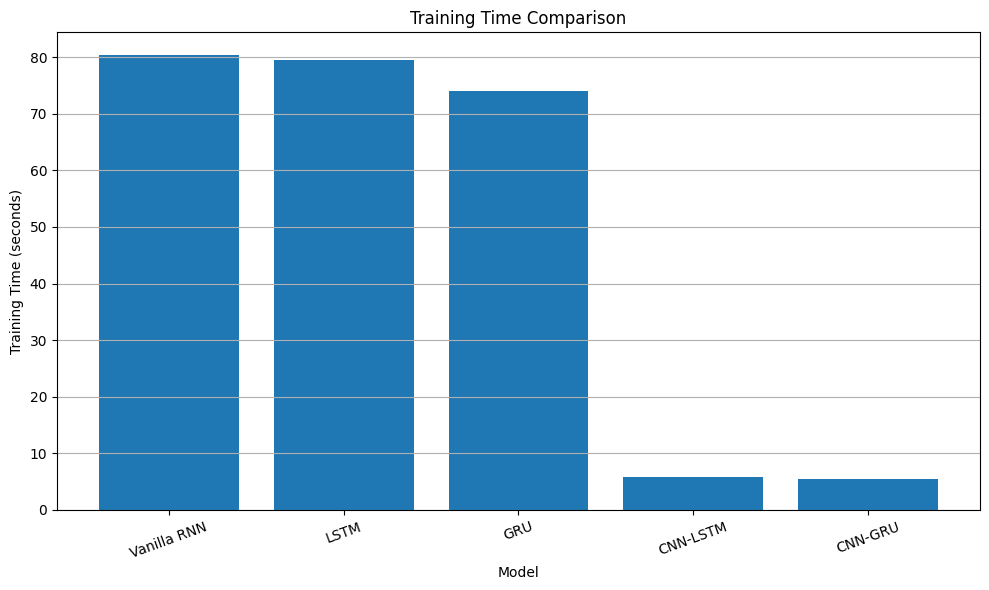

In [117]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_results_df["Model"],
    final_results_df["Training Time (sec)"]
)

plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")

plt.xticks(rotation=20)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [118]:
print("=" * 80)
print("COMPLETE DEEP LEARNING EXPERIMENT SUMMARY")
print("=" * 80)

print("\n1. RECURRENT MODELS")
print("-" * 80)

print(
    comparison_df.round(4).to_string(index=False)
)

print("\n\n2. SEQUENCE LENGTH EXPERIMENT")
print("-" * 80)

print(
    sequence_results_df.round(4).to_string(index=False)
)

print("\n\n3. VIDEO UNDERSTANDING")
print("-" * 80)

print(
    video_comparison_df.round(4).to_string(index=False)
)

print("\n\n4. CONSOLIDATED MODEL COMPARISON")
print("-" * 80)

print(
    final_results_df.round(4).to_string(index=False)
)

print("\n\n5. SEQ2SEQ")
print("-" * 80)

print(
    seq2seq_results_df.to_string(index=False)
)

COMPLETE DEEP LEARNING EXPERIMENT SUMMARY

1. RECURRENT MODELS
--------------------------------------------------------------------------------
Model  Test Accuracy  Macro Precision  Macro Recall  Macro F1  Parameters  Training Time (sec)
  RNN         0.8408           0.8365        0.8350    0.8349        1974              80.3702
 LSTM         0.9502           0.9537        0.9538    0.9534        6006              79.5086
  GRU         0.9508           0.9546        0.9541    0.9538        4758              73.9862


2. SEQUENCE LENGTH EXPERIMENT
--------------------------------------------------------------------------------
 Sequence Length Model  Test Accuracy  Macro F1
              32   RNN         0.8673    0.8648
              32  LSTM         0.9333    0.9363
              32   GRU         0.9333    0.9352
              64   RNN         0.8764    0.8734
              64  LSTM         0.9437    0.9465
              64   GRU         0.9450    0.9483
             128   RNN     

In [119]:
print("=" * 70)
print("SEQUENCE LENGTH ANALYSIS")
print("=" * 70)

for model_name in ["RNN", "LSTM", "GRU"]:

    model_data = sequence_results_df[
        sequence_results_df["Model"] == model_name
    ]

    best_row = model_data.loc[
        model_data["Macro F1"].idxmax()
    ]

    print(f"\n{model_name}")
    print("-" * 40)

    for _, row in model_data.iterrows():
        print(
            f"T = {int(row['Sequence Length'])} "
            f"| Accuracy = {row['Test Accuracy']:.4f} "
            f"| Macro F1 = {row['Macro F1']:.4f}"
        )

    print(
        f"Best sequence length: "
        f"{int(best_row['Sequence Length'])}"
    )

    print(
        f"Best Macro F1: "
        f"{best_row['Macro F1']:.4f}"
    )

SEQUENCE LENGTH ANALYSIS

RNN
----------------------------------------
T = 32 | Accuracy = 0.8673 | Macro F1 = 0.8648
T = 64 | Accuracy = 0.8764 | Macro F1 = 0.8734
T = 128 | Accuracy = 0.8939 | Macro F1 = 0.8945
Best sequence length: 128
Best Macro F1: 0.8945

LSTM
----------------------------------------
T = 32 | Accuracy = 0.9333 | Macro F1 = 0.9363
T = 64 | Accuracy = 0.9437 | Macro F1 = 0.9465
T = 128 | Accuracy = 0.8634 | Macro F1 = 0.8546
Best sequence length: 64
Best Macro F1: 0.9465

GRU
----------------------------------------
T = 32 | Accuracy = 0.9333 | Macro F1 = 0.9352
T = 64 | Accuracy = 0.9450 | Macro F1 = 0.9483
T = 128 | Accuracy = 0.9456 | Macro F1 = 0.9493
Best sequence length: 128
Best Macro F1: 0.9493


In [120]:
print("=" * 70)
print("RECURRENT MODEL PERFORMANCE ANALYSIS")
print("=" * 70)

best_f1_model = final_results_df.loc[
    final_results_df["Macro F1"].idxmax()
]

fastest_model = final_results_df.loc[
    final_results_df["Training Time (sec)"].idxmin()
]

smallest_model = final_results_df.loc[
    final_results_df["Parameters"].idxmin()
]

print("\nHighest observed Macro F1:")
print(
    f"{best_f1_model['Model']} "
    f"({best_f1_model['Macro F1']:.4f})"
)

print("\nLowest observed training time:")
print(
    f"{fastest_model['Model']} "
    f"({fastest_model['Training Time (sec)']:.2f} sec)"
)

print("\nFewest trainable parameters:")
print(
    f"{smallest_model['Model']} "
    f"({int(smallest_model['Parameters'])})"
)

RECURRENT MODEL PERFORMANCE ANALYSIS

Highest observed Macro F1:
CNN-LSTM (1.0000)

Lowest observed training time:
CNN-GRU (5.50 sec)

Fewest trainable parameters:
Vanilla RNN (1974)


In [121]:
print("=" * 70)
print("SEQ2SEQ ANALYSIS")
print("=" * 70)

print(
    f"Token Accuracy    : "
    f"{seq2seq_token_accuracy:.4f}"
)

print(
    f"Sequence Accuracy : "
    f"{seq2seq_sequence_accuracy:.4f}"
)

difference = (
    seq2seq_token_accuracy -
    seq2seq_sequence_accuracy
)

print(
    f"\nToken vs Sequence Accuracy difference: "
    f"{difference:.4f}"
)

print("\nInterpretation:")
print(
    "Token accuracy measures individual token predictions, "
    "whereas sequence accuracy requires every token in an "
    "entire sequence to be correct."
)

SEQ2SEQ ANALYSIS
Token Accuracy    : 0.9994
Sequence Accuracy : 0.9975

Token vs Sequence Accuracy difference: 0.0019

Interpretation:
Token accuracy measures individual token predictions, whereas sequence accuracy requires every token in an entire sequence to be correct.
